# 04 — KoVAE Minimal Comparison Plots

This is the reduced-plot version of Notebook 04.

It keeps only the important comparison:

```text
Real spaced timeline
Real window-based timeline
Synthetic window-based timeline
```

I removed the phrase `center-crop` from the plot titles and saved figure names.

Default output size:

```text
1 real subject × 1 synthetic subject × 2 methods × 6 channels = 12 plots
```

Folders stay the same:

```text
figures/comparison/kovae/rollout_v1/
figures/comparison/kovae/posterior_bank_v2/

results/comparison/kovae/rollout_v1/
results/comparison/kovae/posterior_bank_v2/
```


Notebook 04: KoVAE friend-style comparison adapted to project
Config saved: /home/iailab42/khans1/projects/ir/configs/comparison_timevae_friend_style_config.json
Methods: ['prior_v1']

####################################################################################################
METHOD: prior_v1 (TimeVAE-Prior)
####################################################################################################
Real dir: /home/iailab42/khans1/projects/ir/data/processed/native_rates
Synthetic dir: /home/iailab42/khans1/projects/ir/data/synthetic_subjects/timevae/prior_v1
Figures dir: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1
Results dir: /home/iailab42/khans1/projects/ir/results/comparison/timevae/prior_v1
Loaded real ACC:      (46925, 256, 3)
Loaded synthetic ACC: (30000, 256, 3)
Loaded real BVP:      (46925, 512, 1)
Loaded synthetic BVP: (30000, 512, 1)
Loaded real SLOW:      (46925, 32, 2)
Loaded synthetic SLOW: (30000, 32, 2)

Available real subjects

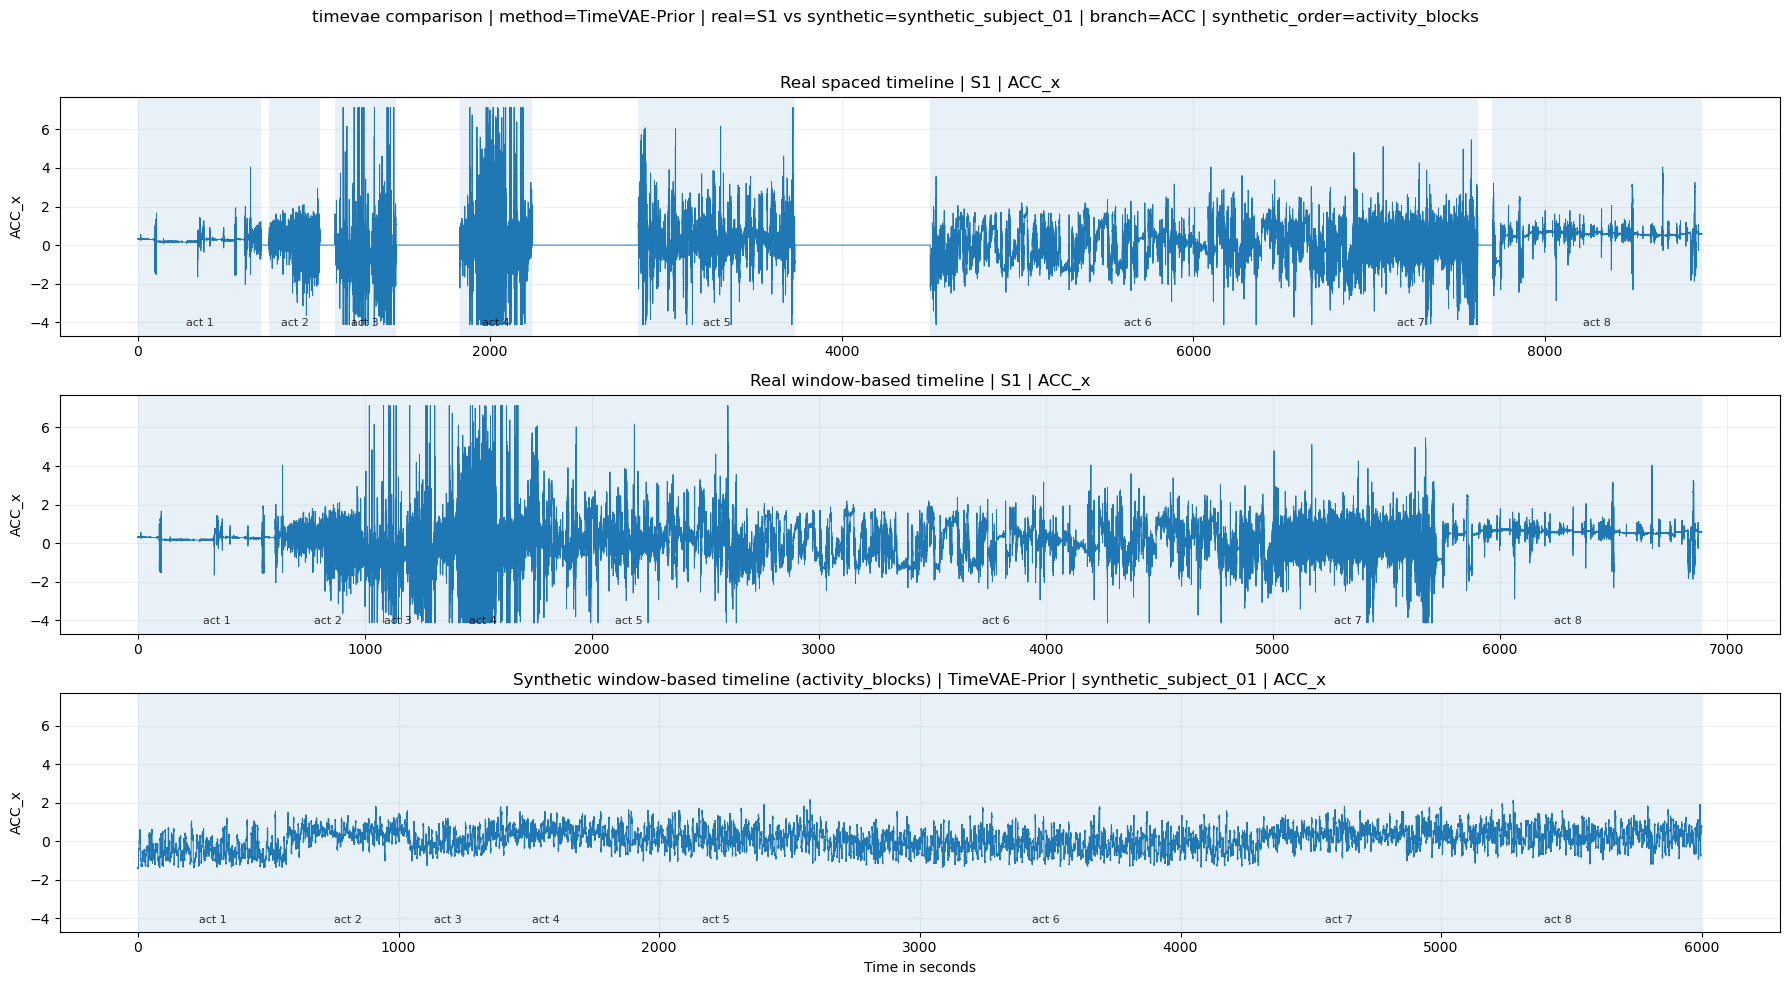

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1/three_way/S1_vs_synthetic_subject_01/ACC_ACC_y_three_way.png


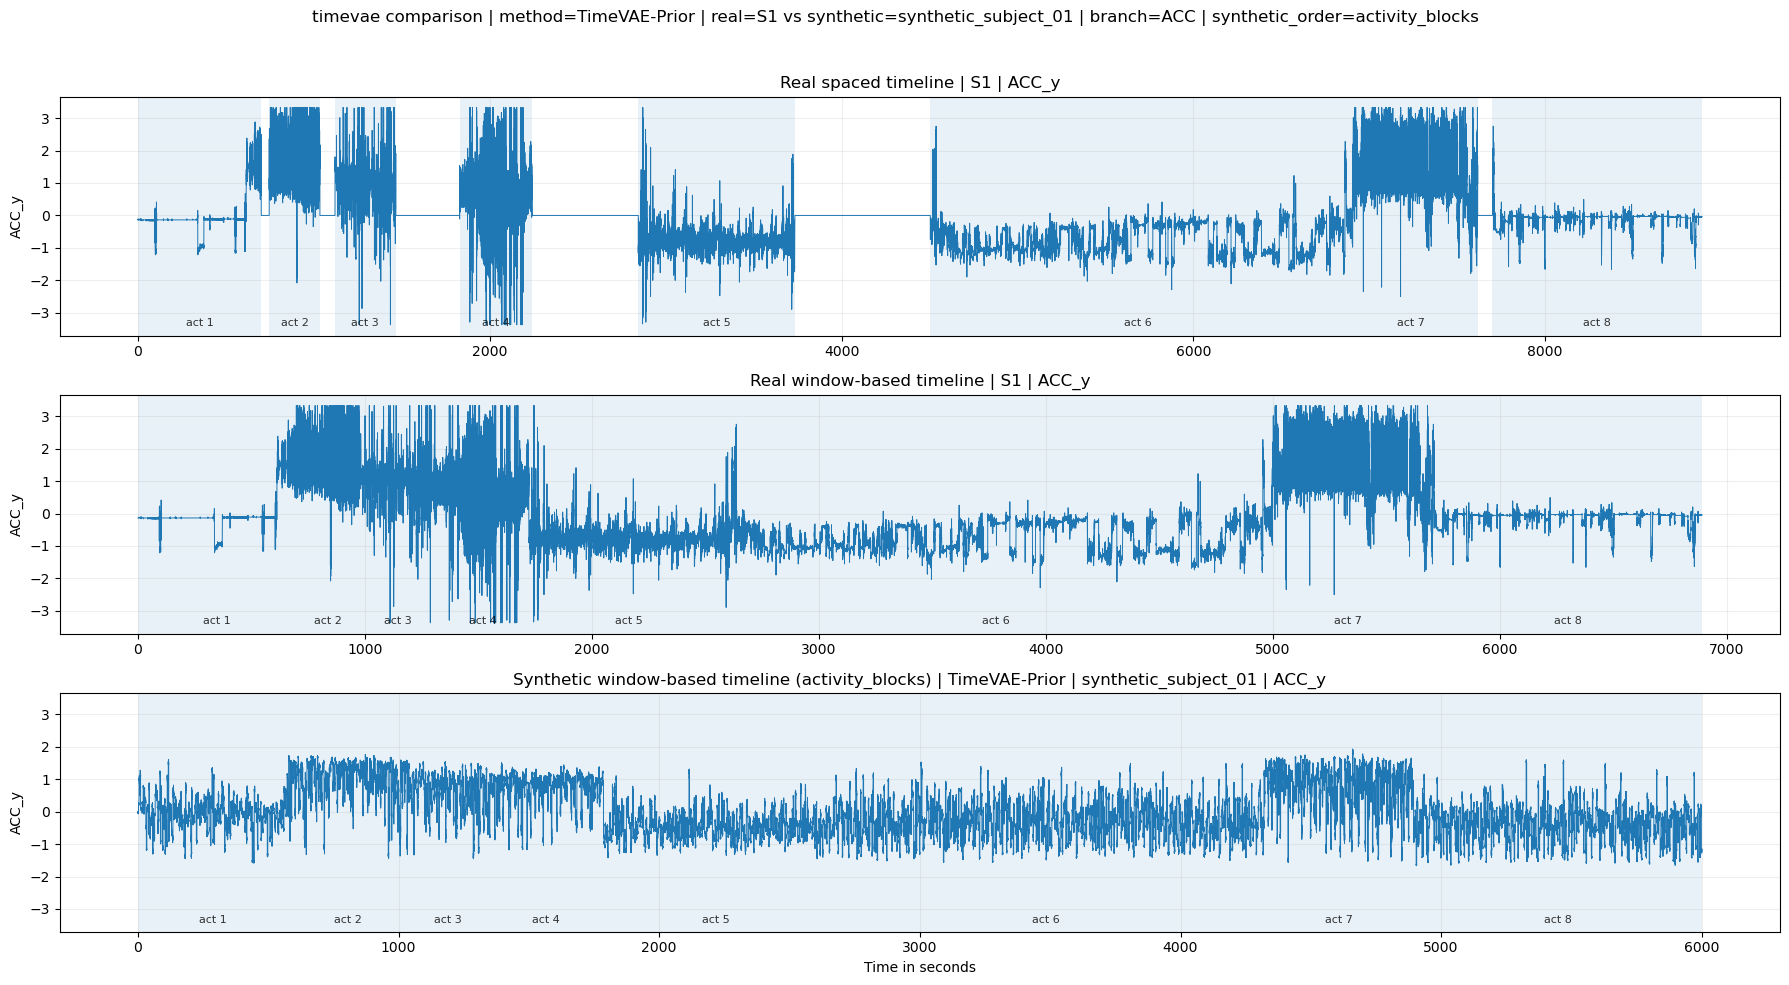

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1/three_way/S1_vs_synthetic_subject_01/ACC_ACC_z_three_way.png


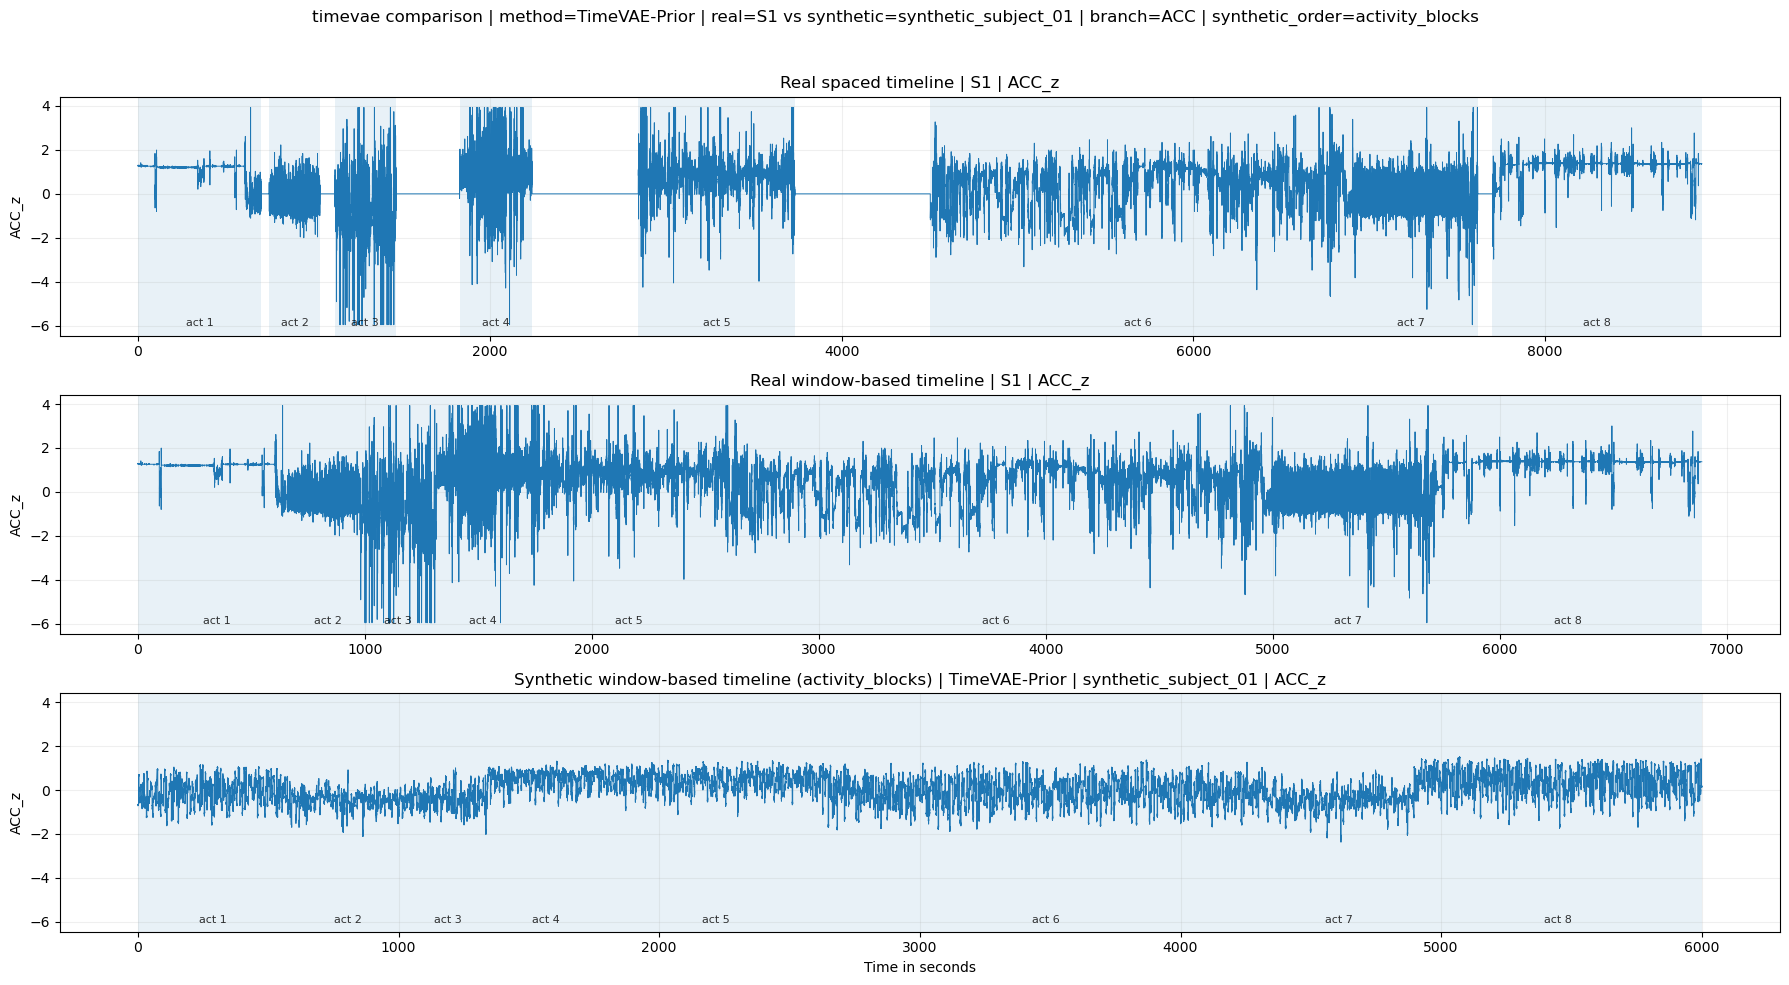


Processing branch: BVP

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=BVP

--------------------------------------------------------------------------------
REAL subject: S1 | branch=BVP
Real S1 BVP: windows=3445 | expected_shift_ratio=0.998 | median_diff=128.0 | max_diff=49792.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1/three_way/S1_vs_synthetic_subject_01/BVP_BVP_three_way.png


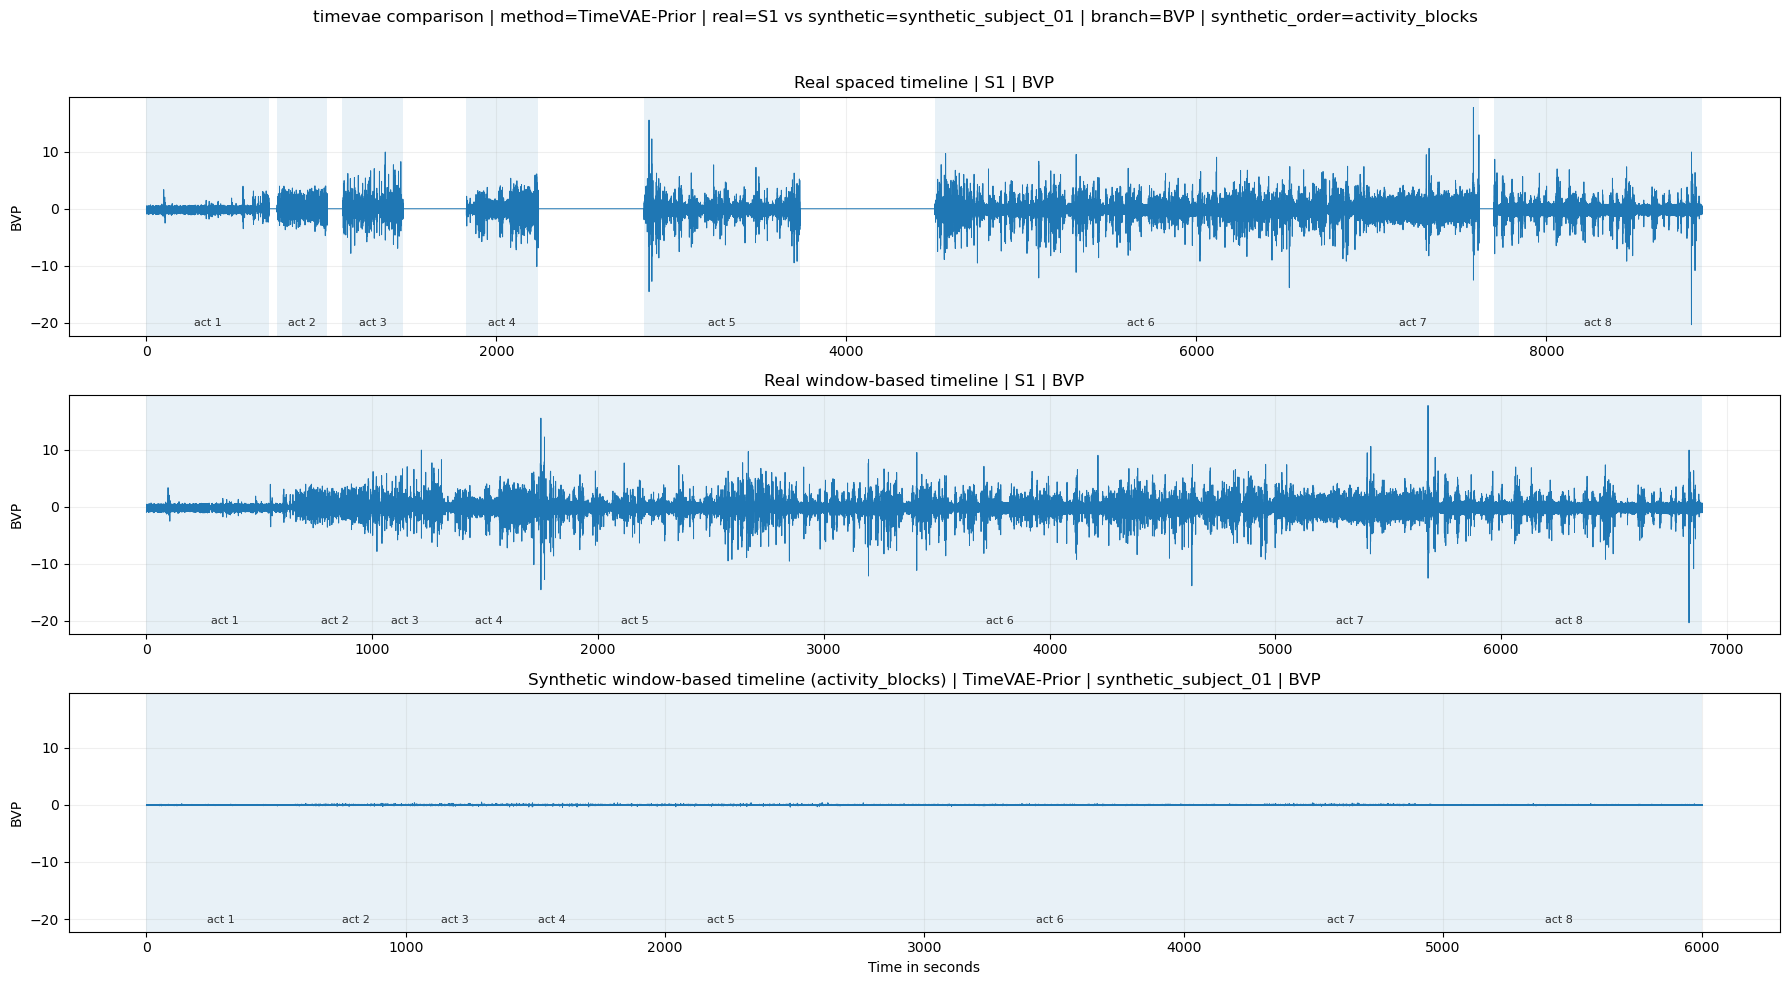


Processing branch: SLOW

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=SLOW

--------------------------------------------------------------------------------
REAL subject: S1 | branch=SLOW
Real S1 SLOW: windows=3445 | expected_shift_ratio=0.998 | median_diff=8.0 | max_diff=3112.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1/three_way/S1_vs_synthetic_subject_01/SLOW_EDA_three_way.png


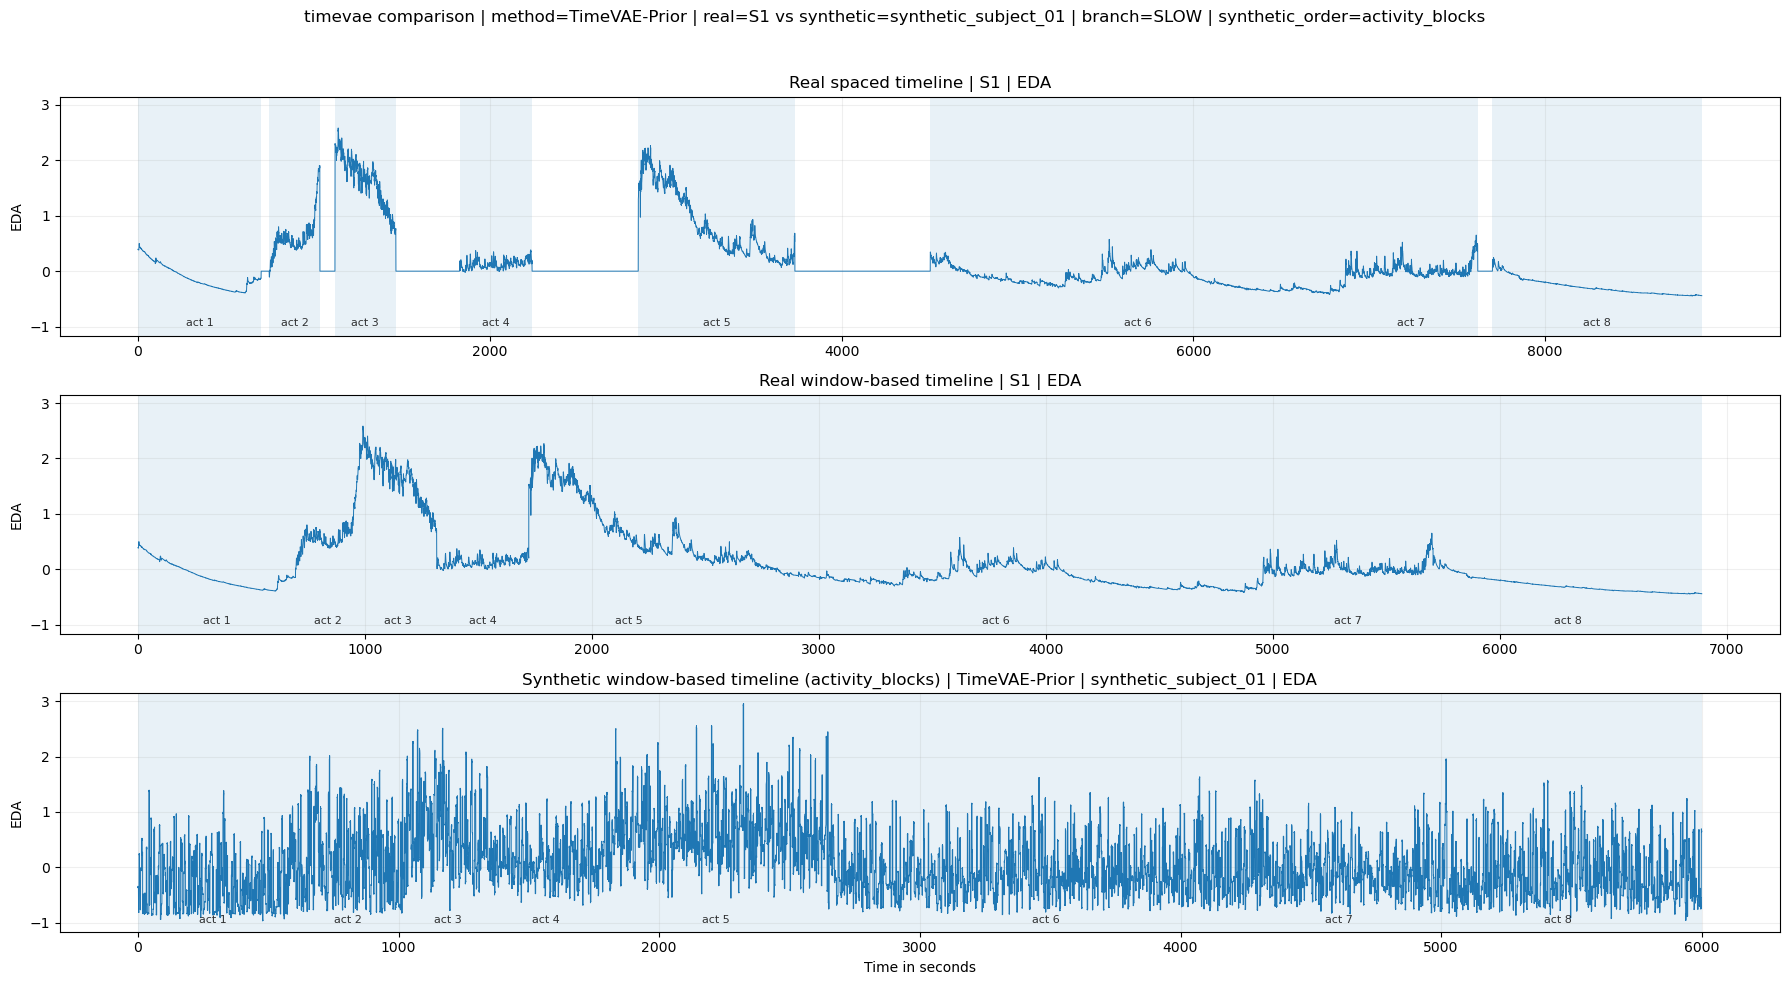

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/timevae/prior_v1/three_way/S1_vs_synthetic_subject_01/SLOW_TEMP_three_way.png


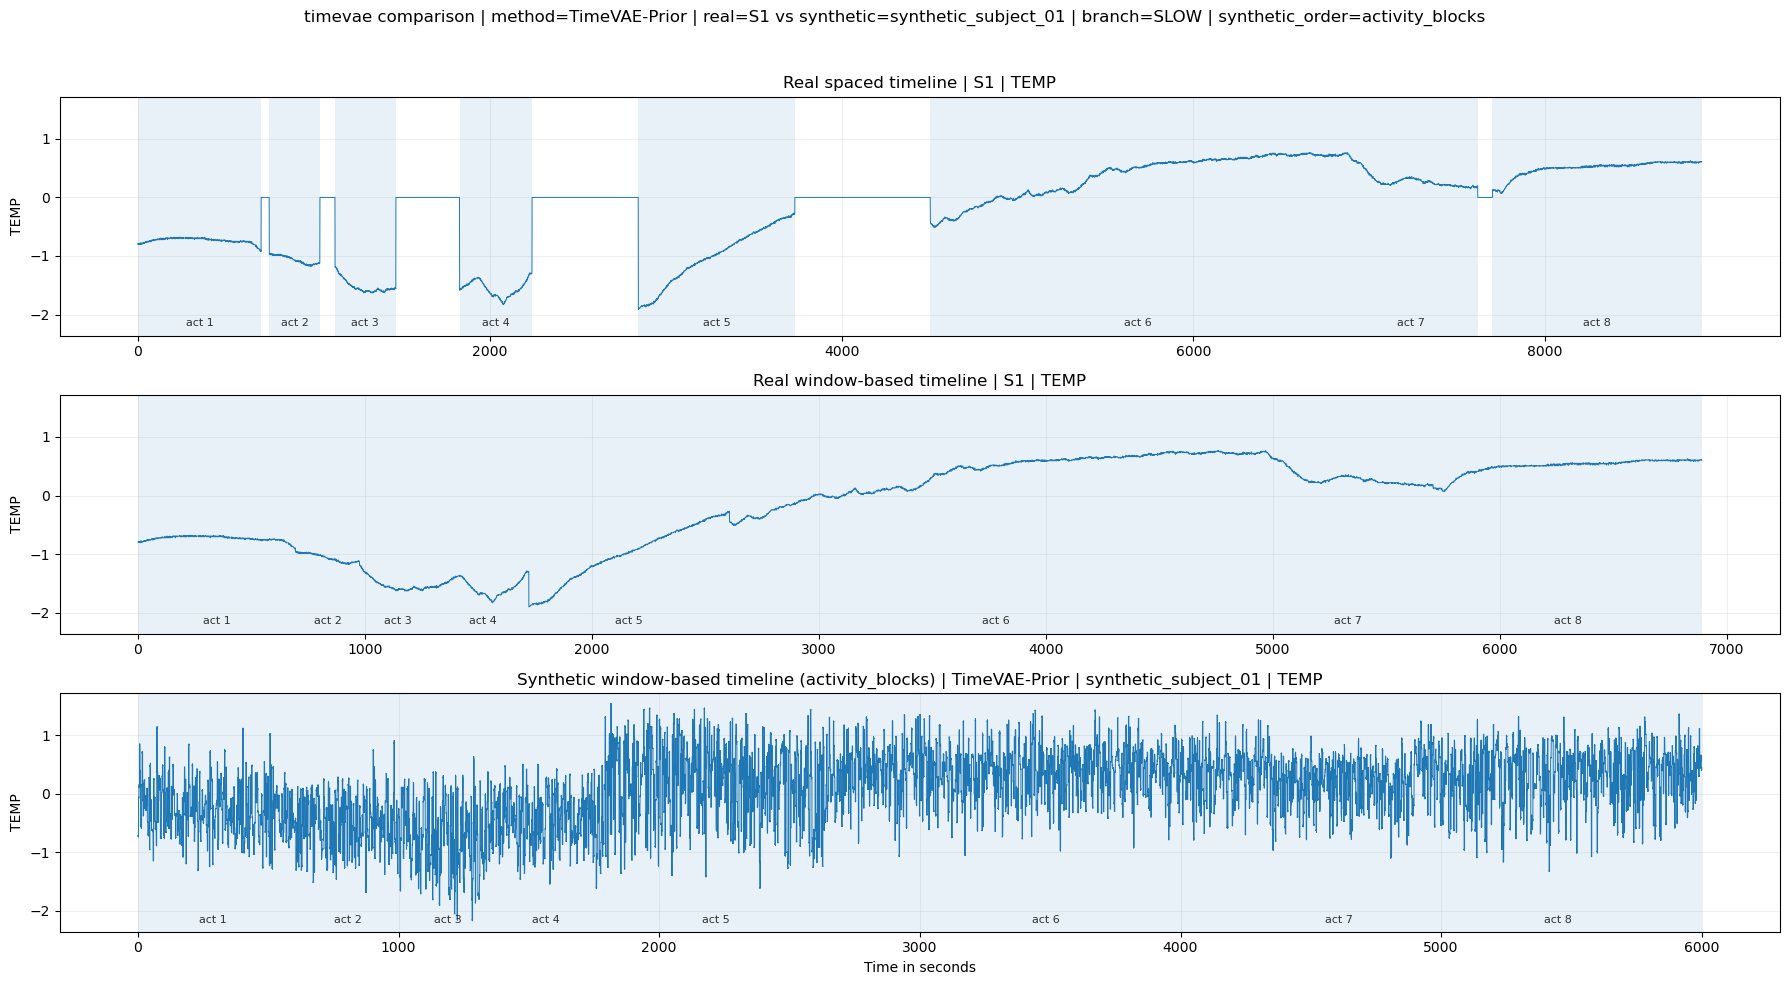

Saved: /home/iailab42/khans1/projects/ir/results/comparison/timevae/prior_v1/summaries/comparison_plot_summary.csv

Done.
Combined CSV: /home/iailab42/khans1/projects/ir/results/comparison/timevae/combined_comparison_plot_summary.csv
Combined JSON: /home/iailab42/khans1/projects/ir/results/comparison/timevae/combined_comparison_summary.json


In [1]:

# ============================================================
# 04_comparison_kovae_friend_style_project.py
#
# Adapted from friend's comparison notebook, but cleaned for this project.
#
# Final project structure:
#   Real:
#       data/processed/native_rates/
#
#   Synthetic KoVAE:
#       data/synthetic_subjects/kovae/rollout_v1/
#       data/synthetic_subjects/kovae/posterior_bank_v2/
#
#   Figures:
#       figures/comparison/kovae/<method>/
#
#   Results:
#       results/comparison/kovae/<method>/
#
# Later TimeVAE can use:
#       data/synthetic_subjects/timevae/<method>/
#       figures/comparison/timevae/<method>/
#       results/comparison/timevae/<method>/
#
# What it plots:
#   1. Real spaced timeline:
#        original native-rate metadata + overlap-add
#
#   2. Real window-based timeline:
#        middle stride-sized chunk from each real window
#
#   3. Synthetic window-based timeline timeline:
#        middle stride-sized chunk from each synthetic window
#
# Important:
#   Synthetic windows are independent generated windows. They are not guaranteed
#   to form a real continuous recording. Therefore, synthetic window-based is the
#   safest visualization. For better interpretability, this notebook can group
#   synthetic windows by activity before plotting.
# ============================================================

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Select model family here
# Options:
#   "kovae"
#   "timevae"
# ============================================================

# SELECTED_MODEL_FAMILY = "kovae"
SELECTED_MODEL_FAMILY = "timevae"


MODEL_FAMILY_CONFIGS = {
    "kovae": {
        "model_family": "kovae",
        "synthetic_base_dir": "data/synthetic_subjects/kovae",
        "methods_to_compare": ["rollout_v1", "posterior_bank_v2"],
        "method_display_names": {
            "rollout_v1": "KoVAE-Rollout",
            "posterior_bank_v2": "KoVAE-Posterior",
        },
    },

    "timevae": {
        "model_family": "timevae",
        "synthetic_base_dir": "data/synthetic_subjects/timevae",
        "methods_to_compare": ["prior_v1"],
        "method_display_names": {
            "prior_v1": "TimeVAE-Prior",
        },
    },
}


# ============================================================
# Configuration
# ============================================================

COMPARISON_CONFIG = {
    "project_root": "/home/iailab42/khans1/projects/ir",

    "real_dir": "data/processed/native_rates",

    "figures_base_dir": "figures/comparison",
    "results_base_dir": "results/comparison",

    # Friend-style comparison candidates.
    "real_subjects_to_compare": ["S1"],
    "synthetic_subject_selection": "first_n",
    "num_synthetic_subjects_to_compare": 1,
    "specific_synthetic_subjects": [],

    # "same_index" -> S1 vs synthetic_01, S2 vs synthetic_02, ...
    # "all_pairs"  -> every selected real subject vs every selected synthetic subject
    "pairing_mode": "same_index",

    # Synthetic order for visualization.
    # "saved_order"     -> use stored order
    # "activity_blocks" -> group synthetic windows by activity label
    "synthetic_plot_order_mode": "activity_blocks",

    # Reconstruction mode for synthetic. Keep "window_based" for final report.
    "synthetic_reconstruction_mode": "window_based",

    # Real spaced overlap-add weight mode.
    "weight_mode": "hann",

    # Optional duration matching.
    "match_duration_for_three_way": False,
    "comparison_duration_sec": None,
    "comparison_start_sec": 0.0,

    # Plot controls.
    "plot_step": 1,
    "use_common_y_axis": True,
    "use_robust_y_axis": False,
    "robust_y_percentiles": [0.5, 99.5],
    "show_activity_background": True,

    # Save controls.
    "save_plot": True,
    "save_individual_plots": False,
    "save_three_way_plots": True,
    "save_continuous_arrays": False,
}

if SELECTED_MODEL_FAMILY not in MODEL_FAMILY_CONFIGS:
    raise ValueError(
        f"Unknown model family: {SELECTED_MODEL_FAMILY}. "
        f"Available options: {list(MODEL_FAMILY_CONFIGS.keys())}"
    )

COMPARISON_CONFIG.update(MODEL_FAMILY_CONFIGS[SELECTED_MODEL_FAMILY])


# ============================================================
# Native branch configs
# ============================================================

BRANCH_CONFIGS = {
    "ACC": {
        "real_filename": "all_X_acc_32hz.npy",
        "syn_filename": "generated_subjects_X_acc_32hz.npy",
        "hz": 32,
        "window_len": 256,
        "shift_len": 64,
        "channel_names": ["ACC_x", "ACC_y", "ACC_z"],
        "start_col": "acc_start_sample_32hz",
        "end_col": "acc_end_sample_32hz",
    },
    "BVP": {
        "real_filename": "all_X_bvp_64hz.npy",
        "syn_filename": "generated_subjects_X_bvp_64hz.npy",
        "hz": 64,
        "window_len": 512,
        "shift_len": 128,
        "channel_names": ["BVP"],
        "start_col": "bvp_start_sample_64hz",
        "end_col": "bvp_end_sample_64hz",
    },
    "SLOW": {
        "real_filename": "all_X_slow_4hz.npy",
        "syn_filename": "generated_subjects_X_slow_4hz.npy",
        "hz": 4,
        "window_len": 32,
        "shift_len": 8,
        "channel_names": ["EDA", "TEMP"],
        "start_col": "slow_start_sample_4hz",
        "end_col": "slow_end_sample_4hz",
    },
}


# ============================================================
# Basic helpers
# ============================================================

def require_file(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return path


def make_dirs(*dirs: Path) -> None:
    for directory in dirs:
        directory.mkdir(parents=True, exist_ok=True)


def save_json(data: Dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def safe_name(value: str) -> str:
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_.-]+", "_", value)
    return value.strip("_")


def natural_sort_key(value):
    text = str(value)
    numbers = re.findall(r"\d+", text)
    if text.startswith("S") and text[1:].isdigit():
        return (0, int(text[1:]))
    if numbers:
        return (1, int(numbers[-1]), text)
    return (2, text)


def method_display_name(method_name: str, config: Dict) -> str:
    return config.get("method_display_names", {}).get(method_name, method_name)


def get_base_paths(config: Dict) -> Dict[str, Path]:
    root = Path(config["project_root"])
    model_family = str(config["model_family"])

    return {
        "root": root,
        "real_dir": root / config["real_dir"],
        "synthetic_base_dir": root / config["synthetic_base_dir"],
        "figures_model_dir": root / config["figures_base_dir"] / model_family,
        "results_model_dir": root / config["results_base_dir"] / model_family,
        "configs_dir": root / "configs",
    }


def get_method_paths(base_paths: Dict[str, Path], method_name: str) -> Dict[str, Path]:
    figures_dir = base_paths["figures_model_dir"] / method_name
    results_dir = base_paths["results_model_dir"] / method_name

    return {
        "figures_dir": figures_dir,
        "results_dir": results_dir,
        "individual_figures_dir": figures_dir / "individual",
        "three_way_figures_dir": figures_dir / "three_way",
        "arrays_dir": results_dir / "continuous_arrays",
        "summaries_dir": results_dir / "summaries",
    }


def check_branch_shape(X: np.ndarray, branch_name: str, cfg: Dict, source_name: str) -> None:
    if X.ndim != 3:
        raise ValueError(f"{source_name} {branch_name}: expected 3D [N,T,C], got {X.shape}")

    if X.shape[1] != int(cfg["window_len"]):
        raise ValueError(
            f"{source_name} {branch_name}: expected window_len={cfg['window_len']}, got {X.shape[1]}"
        )

    if X.shape[2] != len(cfg["channel_names"]):
        raise ValueError(
            f"{source_name} {branch_name}: expected channels={len(cfg['channel_names'])}, got {X.shape[2]}"
        )


# ============================================================
# Loading
# ============================================================

def load_real_common(real_dir: Path) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    y = np.load(require_file(real_dir / "all_y.npy")).astype(np.int64)
    subjects = np.load(require_file(real_dir / "all_subject.npy"), allow_pickle=True).astype(str)

    metadata_path = real_dir / "all_metadata.csv"

    if metadata_path.exists():
        metadata = pd.read_csv(metadata_path)
    else:
        warnings.warn(f"Missing real metadata: {metadata_path}; fallback timing will be used.")
        metadata = pd.DataFrame(index=np.arange(len(y)))

    if len(y) != len(subjects):
        raise ValueError(f"Real y/subject mismatch: {len(y)} vs {len(subjects)}")

    if len(metadata) != len(y):
        raise ValueError(f"Real metadata/y mismatch: {len(metadata)} vs {len(y)}")

    metadata = metadata.copy()
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)
    metadata["subject"] = subjects
    metadata["activity_label"] = y

    return y, subjects, metadata


def load_synthetic_common(synthetic_dir: Path) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    y = np.load(require_file(synthetic_dir / "generated_subjects_all_y.npy")).astype(np.int64)
    subjects = np.load(
        require_file(synthetic_dir / "generated_subjects_all_subject.npy"),
        allow_pickle=True,
    ).astype(str)
    metadata = pd.read_csv(require_file(synthetic_dir / "generated_subjects_metadata.csv"))

    if len(y) != len(subjects):
        raise ValueError(f"Synthetic y/subject mismatch: {len(y)} vs {len(subjects)}")

    if len(metadata) != len(y):
        raise ValueError(f"Synthetic metadata/y mismatch: {len(metadata)} vs {len(y)}")

    metadata = metadata.copy()
    metadata["array_index"] = np.arange(len(y), dtype=np.int64)
    metadata["synthetic_subject"] = subjects
    metadata["activity_label"] = y

    return y, subjects, metadata


def load_branch_arrays(real_dir: Path, synthetic_dir: Path) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    real_X = {}
    syn_X = {}

    for branch_name, cfg in BRANCH_CONFIGS.items():
        real_path = require_file(real_dir / cfg["real_filename"])
        syn_path = require_file(synthetic_dir / cfg["syn_filename"])

        X_real = np.load(real_path).astype(np.float32)
        X_syn = np.load(syn_path).astype(np.float32)

        check_branch_shape(X_real, branch_name, cfg, "Real")
        check_branch_shape(X_syn, branch_name, cfg, "Synthetic")

        real_X[branch_name] = X_real
        syn_X[branch_name] = X_syn

        print(f"Loaded real {branch_name}:      {X_real.shape}")
        print(f"Loaded synthetic {branch_name}: {X_syn.shape}")

    return real_X, syn_X


def load_all_data_for_method(
    real_dir: Path,
    synthetic_dir: Path,
) -> Tuple[
    Dict[str, np.ndarray],
    np.ndarray,
    np.ndarray,
    pd.DataFrame,
    Dict[str, np.ndarray],
    np.ndarray,
    np.ndarray,
    pd.DataFrame,
]:
    real_y, real_subjects, real_meta = load_real_common(real_dir)
    syn_y, syn_subjects, syn_meta = load_synthetic_common(synthetic_dir)
    real_X, syn_X = load_branch_arrays(real_dir, synthetic_dir)

    for branch_name in BRANCH_CONFIGS:
        if len(real_X[branch_name]) != len(real_y):
            raise ValueError(f"Real {branch_name}/y mismatch.")

        if len(syn_X[branch_name]) != len(syn_y):
            raise ValueError(f"Synthetic {branch_name}/y mismatch.")

    return real_X, real_y, real_subjects, real_meta, syn_X, syn_y, syn_subjects, syn_meta


# ============================================================
# Subject selection
# ============================================================

def choose_synthetic_subjects(syn_subjects: np.ndarray, config: Dict) -> List[str]:
    available = sorted(np.unique(syn_subjects.astype(str)).tolist(), key=natural_sort_key)
    mode = config["synthetic_subject_selection"]

    if mode == "first_n":
        n = int(config["num_synthetic_subjects_to_compare"])
        return available[:n]

    if mode == "specific":
        selected = [str(x) for x in config["specific_synthetic_subjects"]]
        missing = sorted(set(selected) - set(available), key=natural_sort_key)
        if missing:
            raise ValueError(f"Missing synthetic subjects: {missing}")
        return selected

    raise ValueError("synthetic_subject_selection must be 'first_n' or 'specific'.")


def build_pairs(real_subjects: List[str], synthetic_subjects: List[str], config: Dict) -> List[Tuple[str, str]]:
    mode = config["pairing_mode"]

    if mode == "same_index":
        n = min(len(real_subjects), len(synthetic_subjects))
        return [(real_subjects[i], synthetic_subjects[i]) for i in range(n)]

    if mode == "all_pairs":
        return [(r, s) for r in real_subjects for s in synthetic_subjects]

    raise ValueError("pairing_mode must be 'same_index' or 'all_pairs'.")


# ============================================================
# Reconstruction
# ============================================================

def make_window_weights(window_len: int, mode: str) -> np.ndarray:
    if mode == "hann":
        weights = np.hanning(window_len).astype(np.float64)
        weights = np.maximum(weights, 1e-4)
        return weights

    if mode == "flat":
        return np.ones(window_len, dtype=np.float64)

    raise ValueError("weight_mode must be 'hann' or 'flat'.")


def ensure_timing_columns(
    metadata: pd.DataFrame,
    subject_col: str,
    start_col: str,
    end_col: str,
    window_len: int,
    shift_len: int,
) -> pd.DataFrame:
    metadata = metadata.copy().reset_index(drop=True)

    if start_col in metadata.columns and end_col in metadata.columns:
        return metadata

    warnings.warn(
        f"Missing timing columns {start_col}/{end_col}. "
        "Using fallback timing based on window order."
    )

    if subject_col not in metadata.columns:
        metadata[subject_col] = "unknown"

    within_subject_index = metadata.groupby(subject_col).cumcount().to_numpy(dtype=np.int64)
    metadata[start_col] = within_subject_index * int(shift_len)
    metadata[end_col] = metadata[start_col] + int(window_len)

    return metadata


def reorder_synthetic_windows(
    windows: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
    mode: str,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    metadata = metadata.copy().reset_index(drop=True)

    if len(windows) != len(labels) or len(labels) != len(metadata):
        raise ValueError(
            f"Reorder length mismatch: windows={len(windows)}, labels={len(labels)}, metadata={len(metadata)}"
        )

    metadata["_row_order"] = np.arange(len(metadata), dtype=np.int64)

    if "activity_label" not in metadata.columns:
        metadata["activity_label"] = labels

    if "array_index" not in metadata.columns:
        metadata["array_index"] = np.arange(len(metadata), dtype=np.int64)

    if mode == "saved_order":
        order = metadata["_row_order"].to_numpy(dtype=np.int64)

    elif mode == "activity_blocks":
        ordered = metadata.sort_values(
            by=["activity_label", "array_index", "_row_order"],
            kind="mergesort",
        )
        order = ordered["_row_order"].to_numpy(dtype=np.int64)

    else:
        raise ValueError("synthetic_plot_order_mode must be 'saved_order' or 'activity_blocks'.")

    return (
        windows[order],
        labels[order],
        metadata.iloc[order].drop(columns=["_row_order"]).reset_index(drop=True),
    )


def print_consecutiveness_report(
    name: str,
    start_samples: np.ndarray,
    expected_shift_len: int,
) -> Dict[str, float]:
    starts = np.asarray(start_samples, dtype=np.int64)

    if len(starts) < 2:
        report = {
            "num_windows": int(len(starts)),
            "num_transitions": 0,
            "expected_shift_ratio": np.nan,
            "median_start_diff": np.nan,
            "max_start_diff": np.nan,
        }
        print(name, report)
        return report

    starts = np.sort(starts)
    diffs = np.diff(starts)

    expected = int(np.sum(diffs == int(expected_shift_len)))

    report = {
        "num_windows": int(len(starts)),
        "num_transitions": int(len(diffs)),
        "num_expected_shift_transitions": expected,
        "expected_shift_ratio": float(expected / max(1, len(diffs))),
        "median_start_diff": float(np.median(diffs)),
        "max_start_diff": float(np.max(diffs)),
    }

    print(
        f"{name}: windows={report['num_windows']} | "
        f"expected_shift_ratio={report['expected_shift_ratio']:.3f} | "
        f"median_diff={report['median_start_diff']:.1f} | "
        f"max_diff={report['max_start_diff']:.1f}"
    )

    return report


def reconstruct_overlap_add(
    windows: np.ndarray,
    labels: np.ndarray,
    start_samples: np.ndarray,
    end_samples: np.ndarray,
    window_len: int,
    weight_mode: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(windows) == 0:
        raise ValueError("Cannot reconstruct empty windows.")

    starts = np.asarray(start_samples, dtype=np.int64)
    ends = np.asarray(end_samples, dtype=np.int64)

    min_start = int(np.min(starts))
    starts = starts - min_start
    ends = ends - min_start

    order = np.argsort(starts)
    windows = windows[order]
    labels = labels[order]
    starts = starts[order]
    ends = ends[order]

    total_len = int(np.max(ends))
    num_channels = windows.shape[-1]

    signal_sum = np.zeros((total_len, num_channels), dtype=np.float64)
    weight_sum = np.zeros((total_len, 1), dtype=np.float64)
    label_scores = np.zeros((total_len, 32), dtype=np.float64)

    weights = make_window_weights(window_len, weight_mode)

    for i in range(len(windows)):
        start = int(starts[i])
        end = int(ends[i])

        if end <= start:
            continue

        segment_len = min(window_len, end - start)
        end = start + segment_len

        w = weights[:segment_len, None]
        signal_sum[start:end] += windows[i, :segment_len, :] * w
        weight_sum[start:end] += w

        label = int(labels[i])
        if 0 <= label < label_scores.shape[1]:
            label_scores[start:end, label] += weights[:segment_len]

    coverage = weight_sum[:, 0]
    valid = coverage > 0

    continuous = np.zeros_like(signal_sum, dtype=np.float32)
    continuous[valid] = (signal_sum[valid] / weight_sum[valid]).astype(np.float32)

    sample_labels = np.argmax(label_scores, axis=1).astype(np.int64)
    sample_labels[~valid] = 0

    return continuous, sample_labels, coverage.astype(np.float32)


def reconstruct_windows_window_based(
    windows: np.ndarray,
    labels: np.ndarray,
    window_len: int,
    shift_len: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if len(windows) == 0:
        raise ValueError("Cannot reconstruct empty windows.")

    if shift_len > window_len:
        raise ValueError("shift_len cannot be larger than window_len.")

    start = (window_len - shift_len) // 2
    end = start + shift_len

    cropped = windows[:, start:end, :].astype(np.float32)
    continuous = cropped.reshape(len(windows) * shift_len, windows.shape[-1])

    sample_labels = np.repeat(labels.astype(np.int64), shift_len)
    coverage = np.ones(len(continuous), dtype=np.float32)

    return continuous, sample_labels, coverage


# ============================================================
# Plotting
# ============================================================

def activity_segments(sample_labels: np.ndarray) -> List[Tuple[int, int, int]]:
    labels = np.asarray(sample_labels, dtype=np.int64)

    if len(labels) == 0:
        return []

    segments = []
    start = 0
    current = int(labels[0])

    for i in range(1, len(labels)):
        label = int(labels[i])
        if label != current:
            segments.append((start, i, current))
            start = i
            current = label

    segments.append((start, len(labels), current))
    return segments


def add_activity_background(ax, sample_labels: np.ndarray, target_hz: float) -> None:
    ymin, ymax = ax.get_ylim()

    if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin == ymax:
        return

    y_text = ymin + 0.03 * (ymax - ymin)

    for start, end, label in activity_segments(sample_labels):
        if int(label) == 0:
            continue

        start_sec = start / float(target_hz)
        end_sec = end / float(target_hz)

        ax.axvspan(start_sec, end_sec, alpha=0.10)

        if end_sec - start_sec >= 10:
            ax.text(
                (start_sec + end_sec) / 2.0,
                y_text,
                f"act {int(label)}",
                ha="center",
                va="bottom",
                fontsize=8,
                alpha=0.8,
            )


def decimate_for_plot(
    time_sec: np.ndarray,
    signal: np.ndarray,
    labels: np.ndarray,
    step: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    step = int(step)
    if step <= 1:
        return time_sec, signal, labels
    return time_sec[::step], signal[::step], labels[::step]


def compute_common_ylim(
    arrays: List[np.ndarray],
    channel_idx: int,
    config: Dict,
) -> Optional[Tuple[float, float]]:
    values = []

    for array in arrays:
        if array is not None and len(array) > 0:
            values.append(array[:, channel_idx].reshape(-1))

    if not values:
        return None

    values = np.concatenate(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return None

    if bool(config["use_robust_y_axis"]):
        low, high = np.percentile(values, config["robust_y_percentiles"])
    else:
        low, high = float(np.min(values)), float(np.max(values))

    if low == high:
        pad = 1.0
    else:
        pad = 0.05 * (high - low)

    return float(low - pad), float(high + pad)


def crop_by_seconds(
    continuous: np.ndarray,
    labels: np.ndarray,
    target_hz: int,
    start_sec: float,
    duration_sec: Optional[float],
) -> Tuple[np.ndarray, np.ndarray]:
    if duration_sec is None:
        return continuous, labels

    start_idx = max(0, int(round(start_sec * target_hz)))
    end_idx = min(len(continuous), start_idx + int(round(duration_sec * target_hz)))

    if end_idx <= start_idx:
        raise ValueError("Invalid crop duration.")

    return continuous[start_idx:end_idx], labels[start_idx:end_idx]


def decide_comparison_duration(
    real_spaced: np.ndarray,
    real_center: np.ndarray,
    syn_center: np.ndarray,
    hz: int,
    config: Dict,
) -> Optional[float]:
    if not bool(config["match_duration_for_three_way"]):
        return None

    available = min(len(real_spaced), len(real_center), len(syn_center)) / float(hz)

    requested = config["comparison_duration_sec"]

    if requested is None:
        return float(available)

    return float(min(float(requested), available))


def plot_one_continuous_branch(
    continuous: np.ndarray,
    sample_labels: np.ndarray,
    title: str,
    save_path: Path,
    channel_names: List[str],
    target_hz: int,
    config: Dict,
) -> None:
    if not bool(config["save_individual_plots"]):
        return

    time_sec = np.arange(len(continuous)) / float(target_hz)
    time_plot, cont_plot, labels_plot = decimate_for_plot(
        time_sec,
        continuous,
        sample_labels,
        int(config["plot_step"]),
    )

    fig, axes = plt.subplots(
        len(channel_names),
        1,
        figsize=(18, max(4, 3 * len(channel_names))),
        sharex=True,
    )

    if len(channel_names) == 1:
        axes = [axes]

    for channel_idx, channel_name in enumerate(channel_names):
        axes[channel_idx].plot(time_plot, cont_plot[:, channel_idx], linewidth=0.7)
        axes[channel_idx].set_title(f"{title} | {channel_name}")
        axes[channel_idx].set_ylabel(channel_name)

        if bool(config["show_activity_background"]):
            add_activity_background(
                axes[channel_idx],
                labels_plot,
                target_hz=target_hz / max(int(config["plot_step"]), 1),
            )

        axes[channel_idx].grid(alpha=0.2)

    axes[-1].set_xlabel("Time in seconds")
    fig.tight_layout()

    if bool(config["save_plot"]):
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    plt.close(fig)


def plot_three_way_channel(
    real_spaced_cont: np.ndarray,
    real_spaced_labels: np.ndarray,
    real_center_cont: np.ndarray,
    real_center_labels: np.ndarray,
    syn_cont: np.ndarray,
    syn_labels: np.ndarray,
    channel_idx: int,
    channel_name: str,
    save_path: Path,
    target_hz: int,
    real_subject_name: str,
    synthetic_subject_name: str,
    method_name: str,
    branch_name: str,
    config: Dict,
) -> None:
    if not bool(config["save_three_way_plots"]):
        return

    duration_sec = decide_comparison_duration(
        real_spaced=real_spaced_cont,
        real_center=real_center_cont,
        syn_center=syn_cont,
        hz=target_hz,
        config=config,
    )

    start_sec = float(config["comparison_start_sec"])

    real_spaced_cont, real_spaced_labels = crop_by_seconds(
        real_spaced_cont,
        real_spaced_labels,
        target_hz=target_hz,
        start_sec=start_sec,
        duration_sec=duration_sec,
    )
    real_center_cont, real_center_labels = crop_by_seconds(
        real_center_cont,
        real_center_labels,
        target_hz=target_hz,
        start_sec=start_sec,
        duration_sec=duration_sec,
    )
    syn_cont, syn_labels = crop_by_seconds(
        syn_cont,
        syn_labels,
        target_hz=target_hz,
        start_sec=start_sec,
        duration_sec=duration_sec,
    )

    real_spaced_time = np.arange(len(real_spaced_cont)) / float(target_hz)
    real_center_time = np.arange(len(real_center_cont)) / float(target_hz)
    syn_time = np.arange(len(syn_cont)) / float(target_hz)

    step = int(config["plot_step"])

    real_spaced_time, real_spaced_plot, real_spaced_labels_plot = decimate_for_plot(
        real_spaced_time,
        real_spaced_cont,
        real_spaced_labels,
        step,
    )
    real_center_time, real_center_plot, real_center_labels_plot = decimate_for_plot(
        real_center_time,
        real_center_cont,
        real_center_labels,
        step,
    )
    syn_time, syn_plot, syn_labels_plot = decimate_for_plot(
        syn_time,
        syn_cont,
        syn_labels,
        step,
    )

    common_ylim = None
    if bool(config["use_common_y_axis"]):
        common_ylim = compute_common_ylim(
            arrays=[real_spaced_plot, real_center_plot, syn_plot],
            channel_idx=channel_idx,
            config=config,
        )

    display_name = method_display_name(method_name, config)

    fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False, sharey=bool(config["use_common_y_axis"]))

    panels = [
        (
            axes[0],
            real_spaced_time,
            real_spaced_plot[:, channel_idx],
            real_spaced_labels_plot,
            f"Real spaced timeline | {real_subject_name} | {channel_name}",
        ),
        (
            axes[1],
            real_center_time,
            real_center_plot[:, channel_idx],
            real_center_labels_plot,
            f"Real window-based timeline | {real_subject_name} | {channel_name}",
        ),
        (
            axes[2],
            syn_time,
            syn_plot[:, channel_idx],
            syn_labels_plot,
            f"Synthetic window-based timeline ({config['synthetic_plot_order_mode']}) | "
            f"{display_name} | {synthetic_subject_name} | {channel_name}",
        ),
    ]

    for ax, time_sec, signal, labels, title in panels:
        ax.plot(time_sec, signal, linewidth=0.7)
        ax.set_title(title)
        ax.set_ylabel(channel_name)

        if common_ylim is not None:
            ax.set_ylim(common_ylim)

        if bool(config["show_activity_background"]):
            add_activity_background(
                ax,
                labels,
                target_hz=target_hz / max(step, 1),
            )

        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Time in seconds")

    crop_note = ""
    if duration_sec is not None:
        crop_note = f" | duration={duration_sec:.1f}s"

    fig.suptitle(
        f"{config['model_family']} comparison | method={display_name} | "
        f"real={real_subject_name} vs synthetic={synthetic_subject_name} | "
        f"branch={branch_name} | synthetic_order={config['synthetic_plot_order_mode']}{crop_note}",
        fontsize=12,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if bool(config["save_plot"]):
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    plt.close(fig)


# ============================================================
# Branch reconstruction pipeline
# ============================================================

def get_real_subject_windows(
    X: np.ndarray,
    y: np.ndarray,
    metadata: pd.DataFrame,
    subject_name: str,
    cfg: Dict,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    meta = metadata.copy()
    mask = meta["subject"].astype(str).to_numpy() == str(subject_name)

    if not np.any(mask):
        raise ValueError(f"Real subject not found: {subject_name}")

    sub = meta.loc[mask].copy().reset_index(drop=True)

    sub = ensure_timing_columns(
        metadata=sub,
        subject_col="subject",
        start_col=cfg["start_col"],
        end_col=cfg["end_col"],
        window_len=int(cfg["window_len"]),
        shift_len=int(cfg["shift_len"]),
    )

    sub = sub.sort_values(cfg["start_col"]).reset_index(drop=True)

    idxs = sub["array_index"].to_numpy(dtype=np.int64)
    windows = X[idxs]
    labels = y[idxs].astype(np.int64)
    starts = sub[cfg["start_col"]].to_numpy(dtype=np.int64)
    ends = sub[cfg["end_col"]].to_numpy(dtype=np.int64)

    return windows, labels, starts, ends, sub


def get_synthetic_subject_windows(
    X: np.ndarray,
    y: np.ndarray,
    metadata: pd.DataFrame,
    subject_name: str,
    cfg: Dict,
    config: Dict,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    meta = metadata.copy()
    mask = meta["synthetic_subject"].astype(str).to_numpy() == str(subject_name)

    if not np.any(mask):
        raise ValueError(f"Synthetic subject not found: {subject_name}")

    sub = meta.loc[mask].copy().reset_index(drop=True)

    if "array_index" not in sub.columns:
        sub["array_index"] = np.arange(len(sub), dtype=np.int64)

    sub = sub.sort_values("array_index").reset_index(drop=True)

    idxs = sub["array_index"].to_numpy(dtype=np.int64)
    windows = X[idxs]
    labels = y[idxs].astype(np.int64)

    windows, labels, sub = reorder_synthetic_windows(
        windows=windows,
        labels=labels,
        metadata=sub,
        mode=str(config["synthetic_plot_order_mode"]),
    )

    return windows, labels, sub


def reconstruct_real_subject_for_branch(
    branch_name: str,
    cfg: Dict,
    real_X_branch: np.ndarray,
    real_y: np.ndarray,
    real_meta: pd.DataFrame,
    real_subject_name: str,
    method_paths: Dict[str, Path],
    config: Dict,
) -> Dict:
    hz = int(cfg["hz"])
    window_len = int(cfg["window_len"])
    shift_len = int(cfg["shift_len"])
    channel_names = cfg["channel_names"]

    safe_subject = safe_name(real_subject_name)

    print("\n" + "-" * 80)
    print(f"REAL subject: {real_subject_name} | branch={branch_name}")

    windows, labels, starts, ends, sub_meta = get_real_subject_windows(
        X=real_X_branch,
        y=real_y,
        metadata=real_meta,
        subject_name=real_subject_name,
        cfg=cfg,
    )

    report = print_consecutiveness_report(
        name=f"Real {real_subject_name} {branch_name}",
        start_samples=starts,
        expected_shift_len=shift_len,
    )

    spaced_cont, spaced_labels, spaced_coverage = reconstruct_overlap_add(
        windows=windows,
        labels=labels,
        start_samples=starts,
        end_samples=ends,
        window_len=window_len,
        weight_mode=str(config["weight_mode"]),
    )

    center_cont, center_labels, center_coverage = reconstruct_windows_window_based(
        windows=windows,
        labels=labels,
        window_len=window_len,
        shift_len=shift_len,
    )

    individual_dir = method_paths["individual_figures_dir"] / "real" / safe_subject

    plot_one_continuous_branch(
        continuous=spaced_cont,
        sample_labels=spaced_labels,
        title=f"Real {real_subject_name} spaced overlap-add | {branch_name}",
        save_path=individual_dir / f"real_{safe_subject}_spaced_overlap_add_{branch_name}.png",
        channel_names=channel_names,
        target_hz=hz,
        config=config,
    )

    plot_one_continuous_branch(
        continuous=center_cont,
        sample_labels=center_labels,
        title=f"Real {real_subject_name} window-based | {branch_name}",
        save_path=individual_dir / f"real_{safe_subject}_window_based_{branch_name}.png",
        channel_names=channel_names,
        target_hz=hz,
        config=config,
    )

    return {
        "real_subject": real_subject_name,
        "windows": windows,
        "labels": labels,
        "spaced_cont": spaced_cont,
        "spaced_labels": spaced_labels,
        "spaced_coverage": spaced_coverage,
        "center_cont": center_cont,
        "center_labels": center_labels,
        "center_coverage": center_coverage,
        "consecutiveness": report,
    }


def reconstruct_synthetic_subject_for_branch(
    branch_name: str,
    cfg: Dict,
    syn_X_branch: np.ndarray,
    syn_y: np.ndarray,
    syn_meta: pd.DataFrame,
    synthetic_subject_name: str,
    method_name: str,
    method_paths: Dict[str, Path],
    config: Dict,
) -> Dict:
    hz = int(cfg["hz"])
    window_len = int(cfg["window_len"])
    shift_len = int(cfg["shift_len"])
    channel_names = cfg["channel_names"]
    safe_subject = safe_name(synthetic_subject_name)

    print("\n" + "-" * 80)
    print(f"SYNTHETIC subject: {synthetic_subject_name} | branch={branch_name}")

    windows, labels, sub_meta = get_synthetic_subject_windows(
        X=syn_X_branch,
        y=syn_y,
        metadata=syn_meta,
        subject_name=synthetic_subject_name,
        cfg=cfg,
        config=config,
    )

    if config["synthetic_reconstruction_mode"] in {"window_based", "center_crop"}:
        cont, sample_labels, coverage = reconstruct_windows_window_based(
            windows=windows,
            labels=labels,
            window_len=window_len,
            shift_len=shift_len,
        )
    elif config["synthetic_reconstruction_mode"] == "overlap_add":
        sub_meta = ensure_timing_columns(
            metadata=sub_meta,
            subject_col="synthetic_subject",
            start_col=cfg["start_col"],
            end_col=cfg["end_col"],
            window_len=window_len,
            shift_len=shift_len,
        )
        starts = sub_meta[cfg["start_col"]].to_numpy(dtype=np.int64)
        ends = sub_meta[cfg["end_col"]].to_numpy(dtype=np.int64)
        cont, sample_labels, coverage = reconstruct_overlap_add(
            windows=windows,
            labels=labels,
            start_samples=starts,
            end_samples=ends,
            window_len=window_len,
            weight_mode=str(config["weight_mode"]),
        )
    else:
        raise ValueError("synthetic_reconstruction_mode must be 'window_based', 'center_crop', or 'overlap_add'.")

    individual_dir = method_paths["individual_figures_dir"] / "synthetic" / safe_subject

    plot_one_continuous_branch(
        continuous=cont,
        sample_labels=sample_labels,
        title=(
            f"Synthetic {synthetic_subject_name} | {method_display_name(method_name, config)} | "
            f"{branch_name} | order={config['synthetic_plot_order_mode']}"
        ),
        save_path=individual_dir / (
            f"synthetic_{safe_subject}_{branch_name}_"
            f"{config['synthetic_plot_order_mode']}_{config['synthetic_reconstruction_mode']}.png"
        ),
        channel_names=channel_names,
        target_hz=hz,
        config=config,
    )

    return {
        "synthetic_subject": synthetic_subject_name,
        "windows": windows,
        "labels": labels,
        "cont": cont,
        "sample_labels": sample_labels,
        "coverage": coverage,
        "metadata": sub_meta,
    }


def save_continuous_npz(path: Path, **arrays) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    print("Saved:", path)


def process_branch(
    branch_name: str,
    cfg: Dict,
    real_X_branch: np.ndarray,
    real_y: np.ndarray,
    real_meta: pd.DataFrame,
    syn_X_branch: np.ndarray,
    syn_y: np.ndarray,
    syn_meta: pd.DataFrame,
    real_subjects_to_compare: List[str],
    synthetic_subjects_to_compare: List[str],
    method_name: str,
    method_paths: Dict[str, Path],
    config: Dict,
) -> List[Dict]:
    print("\n" + "=" * 90)
    print(f"Processing branch: {branch_name}")
    print("=" * 90)

    real_results = {}
    synthetic_results = {}

    for synthetic_subject in synthetic_subjects_to_compare:
        synthetic_results[synthetic_subject] = reconstruct_synthetic_subject_for_branch(
            branch_name=branch_name,
            cfg=cfg,
            syn_X_branch=syn_X_branch,
            syn_y=syn_y,
            syn_meta=syn_meta,
            synthetic_subject_name=synthetic_subject,
            method_name=method_name,
            method_paths=method_paths,
            config=config,
        )

    for real_subject in real_subjects_to_compare:
        real_results[real_subject] = reconstruct_real_subject_for_branch(
            branch_name=branch_name,
            cfg=cfg,
            real_X_branch=real_X_branch,
            real_y=real_y,
            real_meta=real_meta,
            real_subject_name=real_subject,
            method_paths=method_paths,
            config=config,
        )

    pairs = build_pairs(
        real_subjects=real_subjects_to_compare,
        synthetic_subjects=synthetic_subjects_to_compare,
        config=config,
    )

    rows = []
    hz = int(cfg["hz"])

    for real_subject, synthetic_subject in pairs:
        real_result = real_results[real_subject]
        synthetic_result = synthetic_results[synthetic_subject]

        safe_real = safe_name(real_subject)
        safe_syn = safe_name(synthetic_subject)

        if bool(config["save_continuous_arrays"]):
            save_continuous_npz(
                method_paths["arrays_dir"] / f"{safe_real}_vs_{safe_syn}_{branch_name}.npz",
                real_spaced=real_result["spaced_cont"],
                real_spaced_labels=real_result["spaced_labels"],
                real_center=real_result["center_cont"],
                real_center_labels=real_result["center_labels"],
                synthetic=synthetic_result["cont"],
                synthetic_labels=synthetic_result["sample_labels"],
            )

        for channel_idx, channel_name in enumerate(cfg["channel_names"]):
            save_path = (
                method_paths["three_way_figures_dir"]
                / f"{safe_real}_vs_{safe_syn}"
                / f"{branch_name}_{safe_name(channel_name)}_three_way.png"
            )

            plot_three_way_channel(
                real_spaced_cont=real_result["spaced_cont"],
                real_spaced_labels=real_result["spaced_labels"],
                real_center_cont=real_result["center_cont"],
                real_center_labels=real_result["center_labels"],
                syn_cont=synthetic_result["cont"],
                syn_labels=synthetic_result["sample_labels"],
                channel_idx=channel_idx,
                channel_name=channel_name,
                save_path=save_path,
                target_hz=hz,
                real_subject_name=real_subject,
                synthetic_subject_name=synthetic_subject,
                method_name=method_name,
                branch_name=branch_name,
                config=config,
            )

            duration_sec = decide_comparison_duration(
                real_spaced=real_result["spaced_cont"],
                real_center=real_result["center_cont"],
                syn_center=synthetic_result["cont"],
                hz=hz,
                config=config,
            )

            rows.append(
                {
                    "model_family": config["model_family"],
                    "method": method_name,
                    "method_display_name": method_display_name(method_name, config),
                    "real_subject": real_subject,
                    "synthetic_subject": synthetic_subject,
                    "branch": branch_name,
                    "channel": channel_name,
                    "hz": hz,
                    "window_len": int(cfg["window_len"]),
                    "shift_len": int(cfg["shift_len"]),
                    "real_num_windows": int(len(real_result["windows"])),
                    "synthetic_num_windows": int(len(synthetic_result["windows"])),
                    "real_spaced_duration_sec": float(len(real_result["spaced_cont"]) / hz),
                    "real_center_duration_sec": float(len(real_result["center_cont"]) / hz),
                    "synthetic_duration_sec": float(len(synthetic_result["cont"]) / hz),
                    "comparison_duration_sec": None if duration_sec is None else float(duration_sec),
                    "synthetic_plot_order_mode": config["synthetic_plot_order_mode"],
                    "synthetic_reconstruction_mode": config["synthetic_reconstruction_mode"],
                    "real_expected_shift_ratio": real_result["consecutiveness"]["expected_shift_ratio"],
                    "figure_path": str(save_path),
                }
            )

    return rows


def process_one_method(method_name: str, config: Dict) -> pd.DataFrame:
    base_paths = get_base_paths(config)
    synthetic_dir = base_paths["synthetic_base_dir"] / method_name
    method_paths = get_method_paths(base_paths, method_name)

    make_dirs(
        method_paths["figures_dir"],
        method_paths["results_dir"],
        method_paths["individual_figures_dir"],
        method_paths["three_way_figures_dir"],
        method_paths["arrays_dir"],
        method_paths["summaries_dir"],
    )

    print("\n" + "#" * 100)
    print(f"METHOD: {method_name} ({method_display_name(method_name, config)})")
    print("#" * 100)
    print("Real dir:", base_paths["real_dir"])
    print("Synthetic dir:", synthetic_dir)
    print("Figures dir:", method_paths["figures_dir"])
    print("Results dir:", method_paths["results_dir"])

    (
        real_X,
        real_y,
        real_subjects,
        real_meta,
        syn_X,
        syn_y,
        syn_subjects,
        syn_meta,
    ) = load_all_data_for_method(
        real_dir=base_paths["real_dir"],
        synthetic_dir=synthetic_dir,
    )

    available_real = sorted(np.unique(real_subjects.astype(str)).tolist(), key=natural_sort_key)
    available_syn = sorted(np.unique(syn_subjects.astype(str)).tolist(), key=natural_sort_key)

    selected_real = [str(s) for s in config["real_subjects_to_compare"]]
    missing_real = sorted(set(selected_real) - set(available_real), key=natural_sort_key)

    if missing_real:
        raise ValueError(f"Requested real subjects not found: {missing_real}")

    selected_syn = choose_synthetic_subjects(syn_subjects, config)

    print("\nAvailable real subjects:", available_real)
    print("Available synthetic subjects:", available_syn[:20])
    print("Selected real subjects:", selected_real)
    print("Selected synthetic subjects:", selected_syn)
    print("Pairing mode:", config["pairing_mode"])
    print("Synthetic plot order:", config["synthetic_plot_order_mode"])

    rows = []

    for branch_name, cfg in BRANCH_CONFIGS.items():
        rows.extend(
            process_branch(
                branch_name=branch_name,
                cfg=cfg,
                real_X_branch=real_X[branch_name],
                real_y=real_y,
                real_meta=real_meta,
                syn_X_branch=syn_X[branch_name],
                syn_y=syn_y,
                syn_meta=syn_meta,
                real_subjects_to_compare=selected_real,
                synthetic_subjects_to_compare=selected_syn,
                method_name=method_name,
                method_paths=method_paths,
                config=config,
            )
        )

    summary_df = pd.DataFrame(rows)
    summary_csv = method_paths["summaries_dir"] / "comparison_plot_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print("Saved:", summary_csv)

    method_summary = {
        "model_family": config["model_family"],
        "method": method_name,
        "method_display_name": method_display_name(method_name, config),
        "synthetic_dir": str(synthetic_dir),
        "figures_dir": str(method_paths["figures_dir"]),
        "results_dir": str(method_paths["results_dir"]),
        "selected_real_subjects": selected_real,
        "selected_synthetic_subjects": selected_syn,
        "pairing_mode": config["pairing_mode"],
        "synthetic_plot_order_mode": config["synthetic_plot_order_mode"],
        "synthetic_reconstruction_mode": config["synthetic_reconstruction_mode"],
        "uses_friend_style_three_way_comparison": True,
        "num_summary_rows": int(len(summary_df)),
        "summary_csv": str(summary_csv),
    }

    save_json(method_summary, method_paths["summaries_dir"] / "method_comparison_summary.json")

    return summary_df


# ============================================================
# Main
# ============================================================

def main(config: Dict = COMPARISON_CONFIG) -> Dict[str, object]:
    base_paths = get_base_paths(config)

    make_dirs(
        base_paths["figures_model_dir"],
        base_paths["results_model_dir"],
        base_paths["configs_dir"],
    )

    config_path = base_paths["configs_dir"] / f"comparison_{config['model_family']}_friend_style_config.json"
    save_json(config, config_path)

    print("=" * 100)
    print("Notebook 04: KoVAE friend-style comparison adapted to project")
    print("=" * 100)
    print("Config saved:", config_path)
    print("Methods:", config["methods_to_compare"])

    method_dfs = {}

    for method_name in config["methods_to_compare"]:
        method_dfs[method_name] = process_one_method(method_name, config)

    combined_df = pd.concat(method_dfs.values(), ignore_index=True)
    combined_csv = base_paths["results_model_dir"] / "combined_comparison_plot_summary.csv"
    combined_df.to_csv(combined_csv, index=False)

    combined_summary = {
        "model_family": config["model_family"],
        "methods_to_compare": config["methods_to_compare"],
        "method_display_names": {
            method: method_display_name(method, config)
            for method in config["methods_to_compare"]
        },
        "synthetic_plot_order_mode": config["synthetic_plot_order_mode"],
        "synthetic_reconstruction_mode": config["synthetic_reconstruction_mode"],
        "figures_model_dir": str(base_paths["figures_model_dir"]),
        "results_model_dir": str(base_paths["results_model_dir"]),
        "combined_summary_csv": str(combined_csv),
        "num_plot_rows": int(len(combined_df)),
        "foldering_note": {
            "kovae": "figures/comparison/kovae/<method>/ and results/comparison/kovae/<method>/",
            "future_timevae": "figures/comparison/timevae/<method>/ and results/comparison/timevae/<method>/",
        },
    }

    combined_json = base_paths["results_model_dir"] / "combined_comparison_summary.json"
    save_json(combined_summary, combined_json)

    print("\nDone.")
    print("Combined CSV:", combined_csv)
    print("Combined JSON:", combined_json)

    return {
        "combined_summary": combined_summary,
        "combined_df": combined_df,
        "method_dfs": method_dfs,
    }


if __name__ == "__main__":
    outputs = main(COMPARISON_CONFIG)


## Minimal final run

This version creates only the useful three-way comparison plots.

Default:

```python
COMPARISON_CONFIG["real_subjects_to_compare"] = ["S1"]
COMPARISON_CONFIG["num_synthetic_subjects_to_compare"] = 1
COMPARISON_CONFIG["save_individual_plots"] = False
COMPARISON_CONFIG["save_three_way_plots"] = True
```

The plot titles use:

```text
Real window-based timeline
Synthetic window-based timeline
```

not `center-crop`.

Total plots:

```text
12 plots
```

because:

```text
2 methods × 6 channels = 12
```


Notebook 04: KoVAE friend-style comparison adapted to project
Config saved: /home/iailab42/khans1/projects/ir/configs/comparison_kovae_friend_style_config.json
Methods: ['rollout_v1', 'posterior_bank_v2']

####################################################################################################
METHOD: rollout_v1 (KoVAE-Rollout)
####################################################################################################
Real dir: /home/iailab42/khans1/projects/ir/data/processed/native_rates
Synthetic dir: /home/iailab42/khans1/projects/ir/data/synthetic_subjects/kovae/rollout_v1
Figures dir: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1
Results dir: /home/iailab42/khans1/projects/ir/results/comparison/kovae/rollout_v1
Loaded real ACC:      (46925, 256, 3)
Loaded synthetic ACC: (30000, 256, 3)
Loaded real BVP:      (46925, 512, 1)
Loaded synthetic BVP: (30000, 512, 1)
Loaded real SLOW:      (46925, 32, 2)
Loaded synthetic SLOW: (30000, 32, 2)



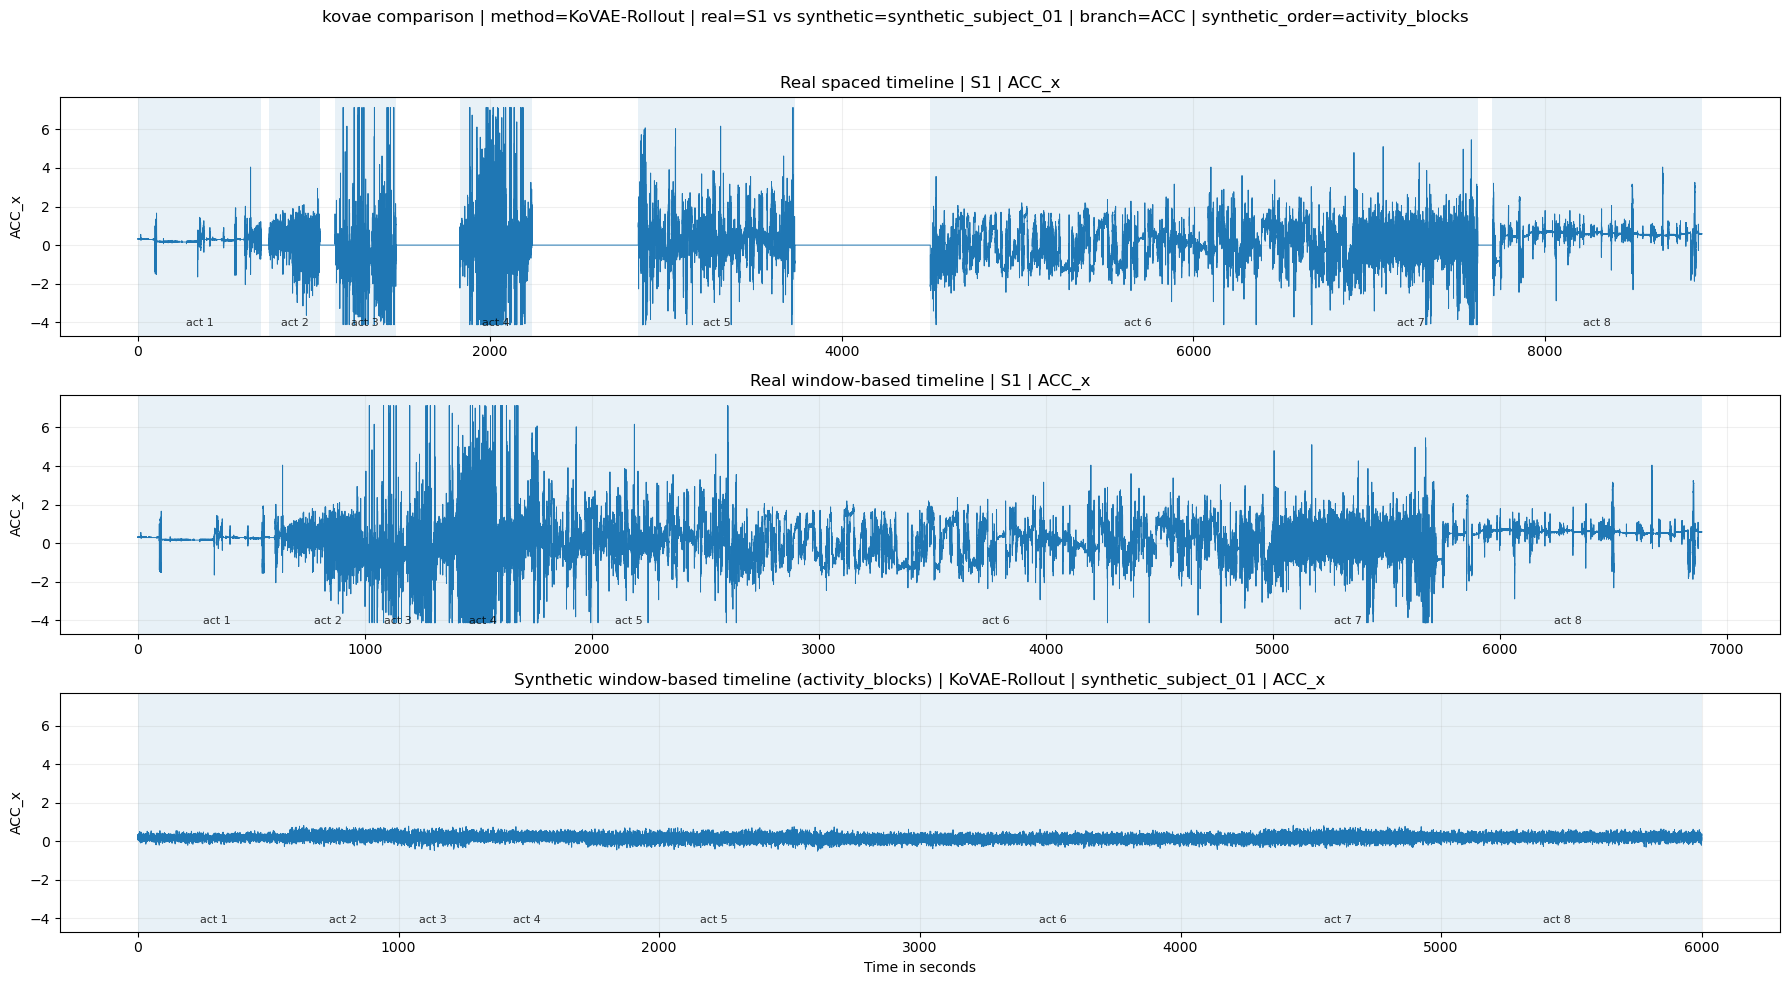

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1/three_way/S1_vs_synthetic_subject_01/ACC_ACC_y_three_way.png


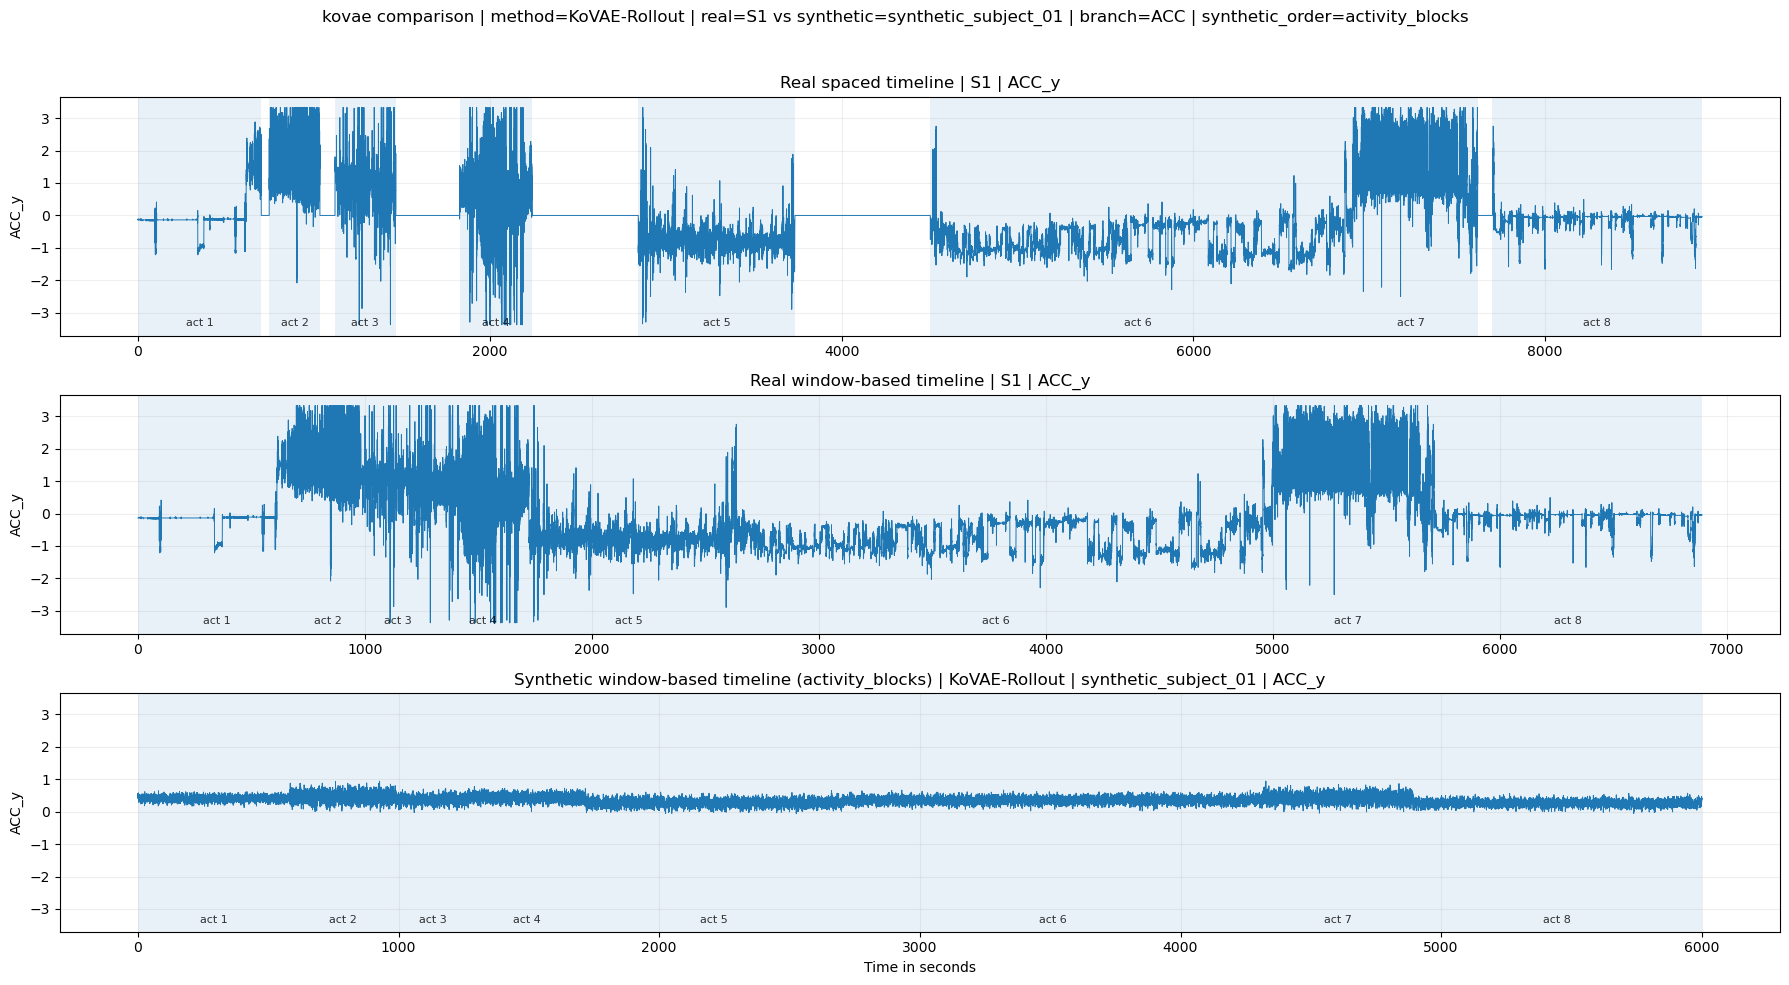

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1/three_way/S1_vs_synthetic_subject_01/ACC_ACC_z_three_way.png


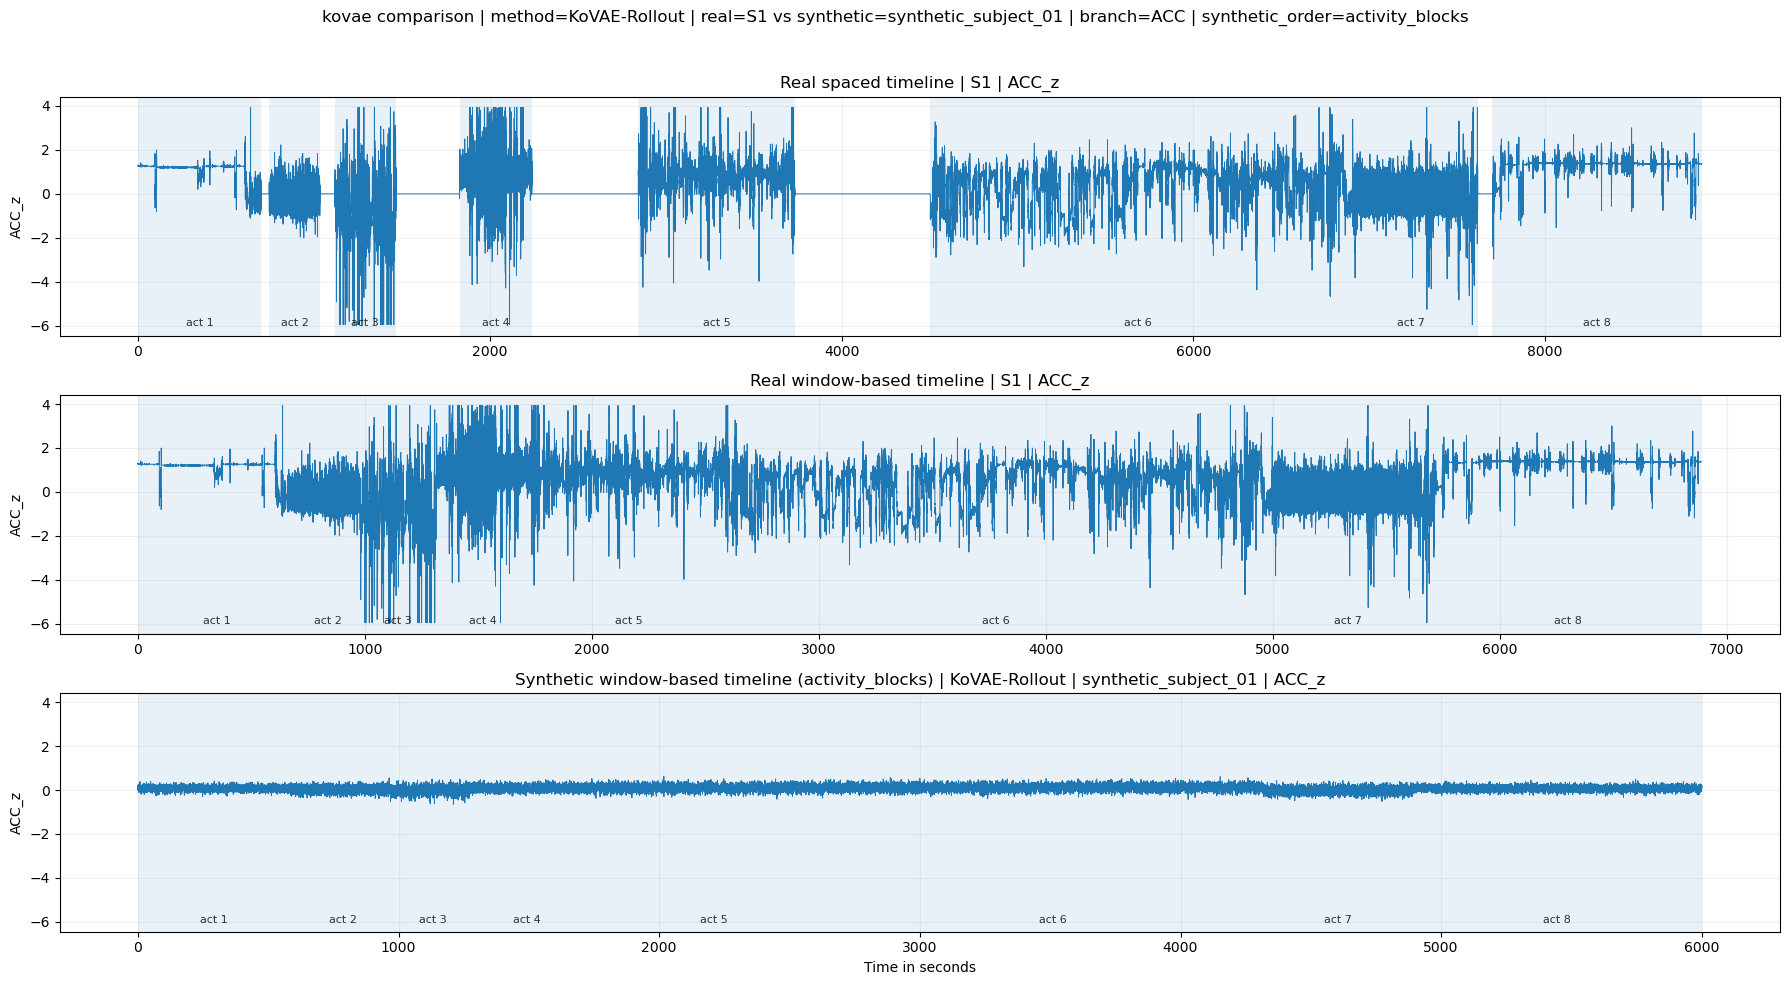


Processing branch: BVP

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=BVP

--------------------------------------------------------------------------------
REAL subject: S1 | branch=BVP
Real S1 BVP: windows=3445 | expected_shift_ratio=0.998 | median_diff=128.0 | max_diff=49792.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1/three_way/S1_vs_synthetic_subject_01/BVP_BVP_three_way.png


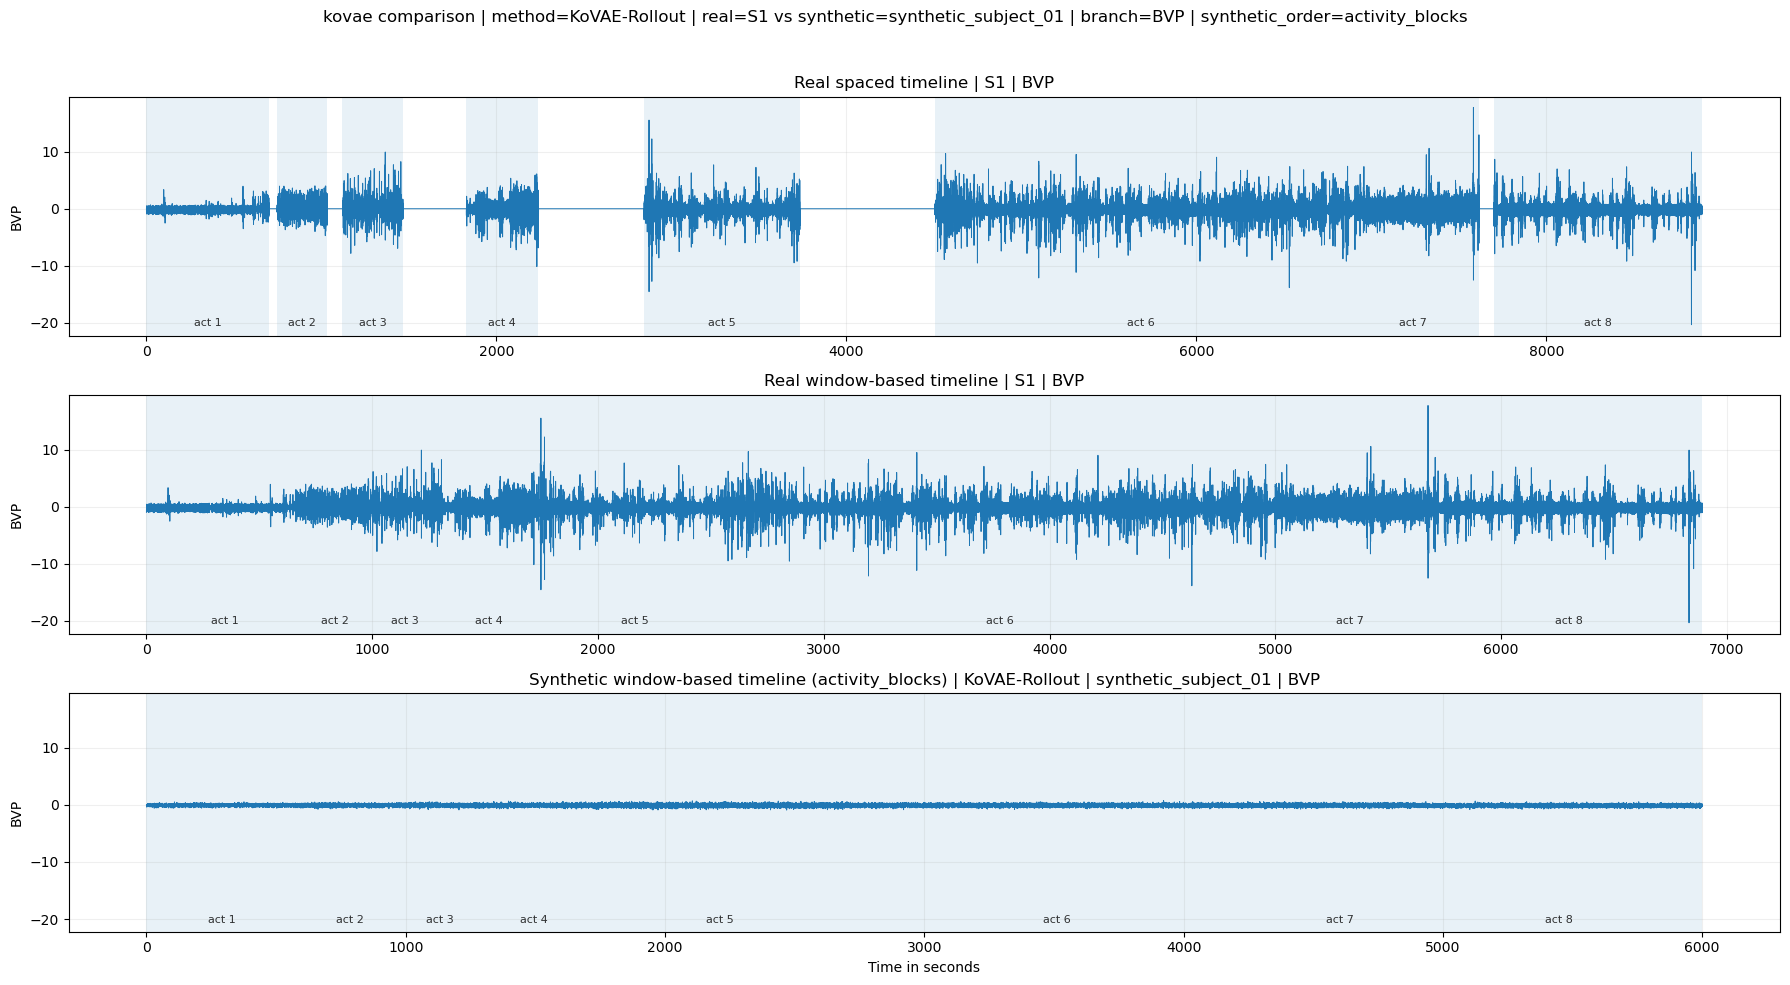


Processing branch: SLOW

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=SLOW

--------------------------------------------------------------------------------
REAL subject: S1 | branch=SLOW
Real S1 SLOW: windows=3445 | expected_shift_ratio=0.998 | median_diff=8.0 | max_diff=3112.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1/three_way/S1_vs_synthetic_subject_01/SLOW_EDA_three_way.png


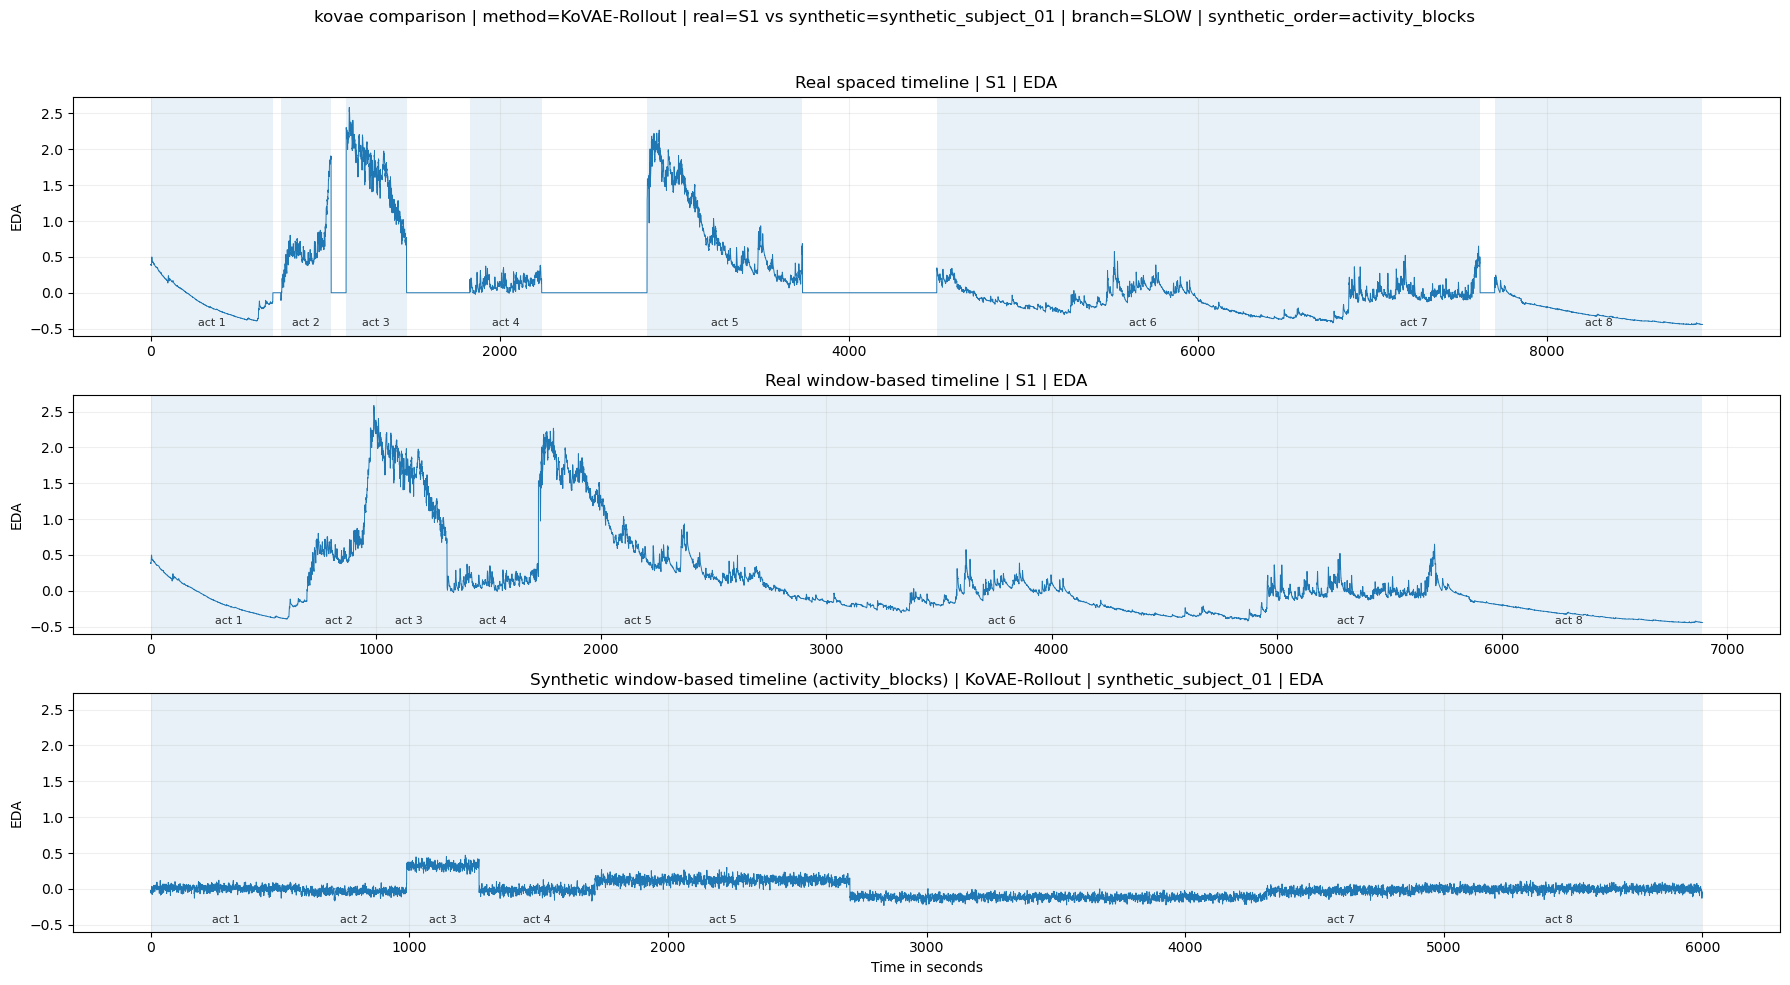

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/rollout_v1/three_way/S1_vs_synthetic_subject_01/SLOW_TEMP_three_way.png


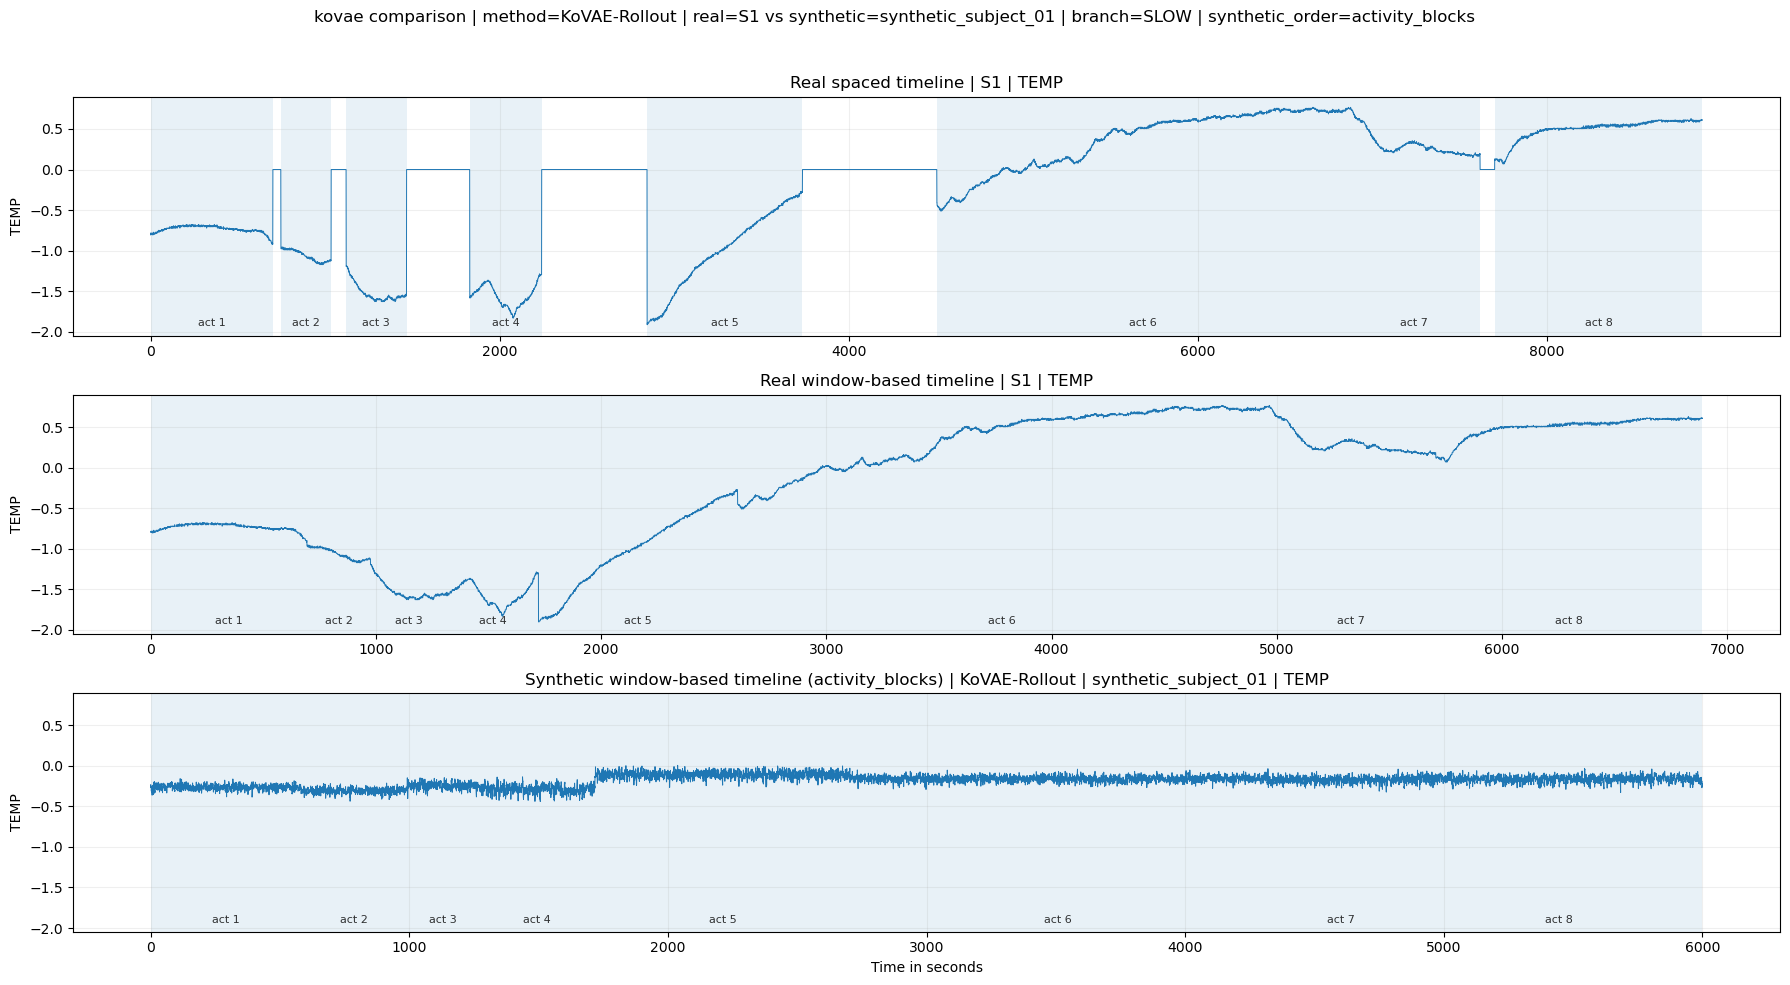

Saved: /home/iailab42/khans1/projects/ir/results/comparison/kovae/rollout_v1/summaries/comparison_plot_summary.csv

####################################################################################################
METHOD: posterior_bank_v2 (KoVAE-Posterior)
####################################################################################################
Real dir: /home/iailab42/khans1/projects/ir/data/processed/native_rates
Synthetic dir: /home/iailab42/khans1/projects/ir/data/synthetic_subjects/kovae/posterior_bank_v2
Figures dir: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2
Results dir: /home/iailab42/khans1/projects/ir/results/comparison/kovae/posterior_bank_v2
Loaded real ACC:      (46925, 256, 3)
Loaded synthetic ACC: (30000, 256, 3)
Loaded real BVP:      (46925, 512, 1)
Loaded synthetic BVP: (30000, 512, 1)
Loaded real SLOW:      (46925, 32, 2)
Loaded synthetic SLOW: (30000, 32, 2)

Available real subjects: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6'

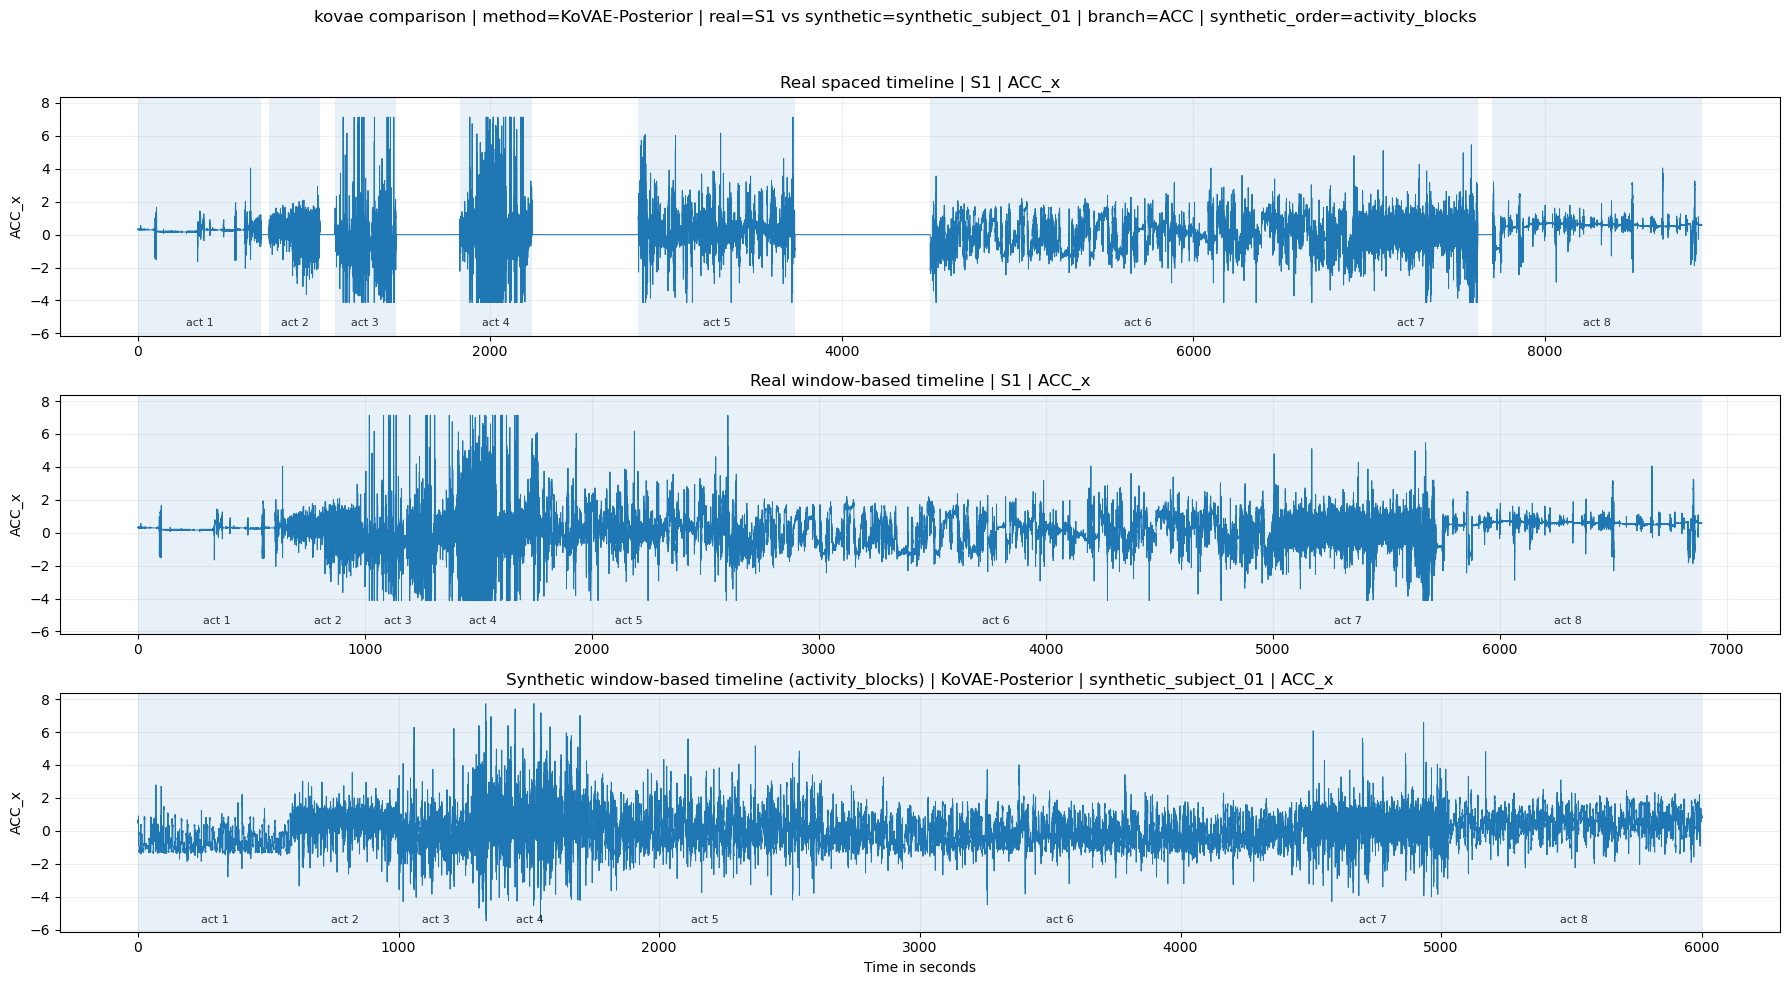

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2/three_way/S1_vs_synthetic_subject_01/ACC_ACC_y_three_way.png


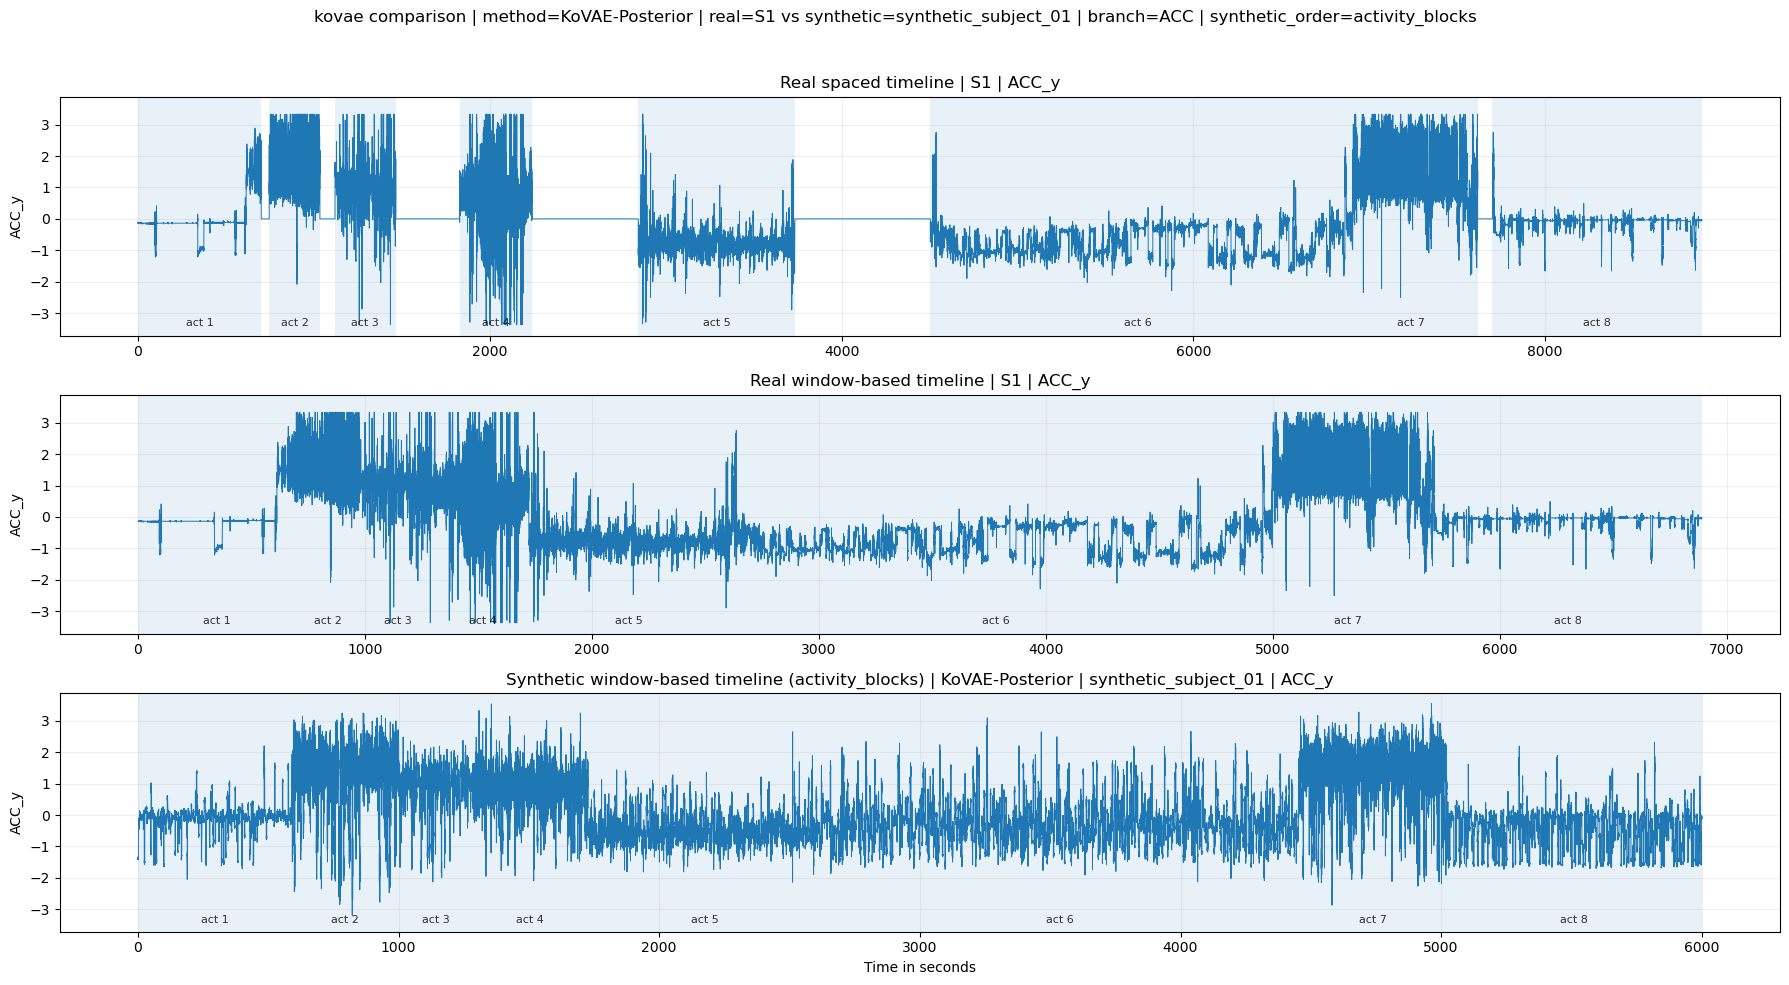

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2/three_way/S1_vs_synthetic_subject_01/ACC_ACC_z_three_way.png


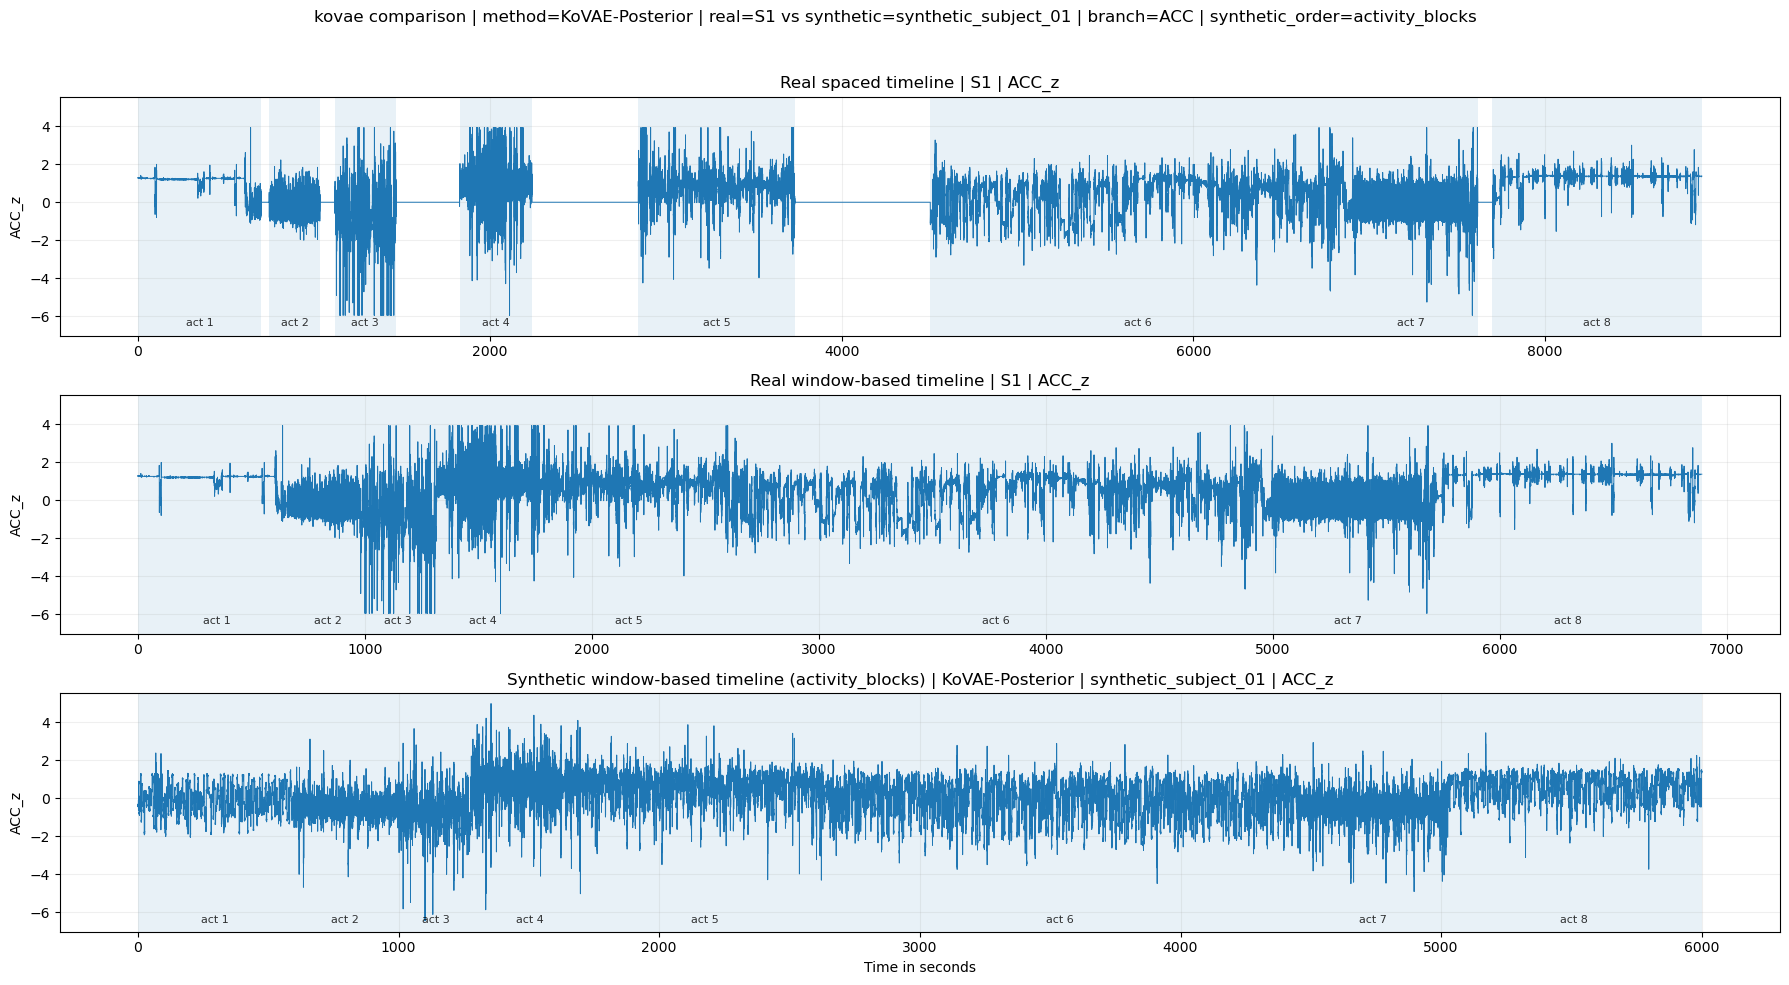


Processing branch: BVP

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=BVP

--------------------------------------------------------------------------------
REAL subject: S1 | branch=BVP
Real S1 BVP: windows=3445 | expected_shift_ratio=0.998 | median_diff=128.0 | max_diff=49792.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2/three_way/S1_vs_synthetic_subject_01/BVP_BVP_three_way.png


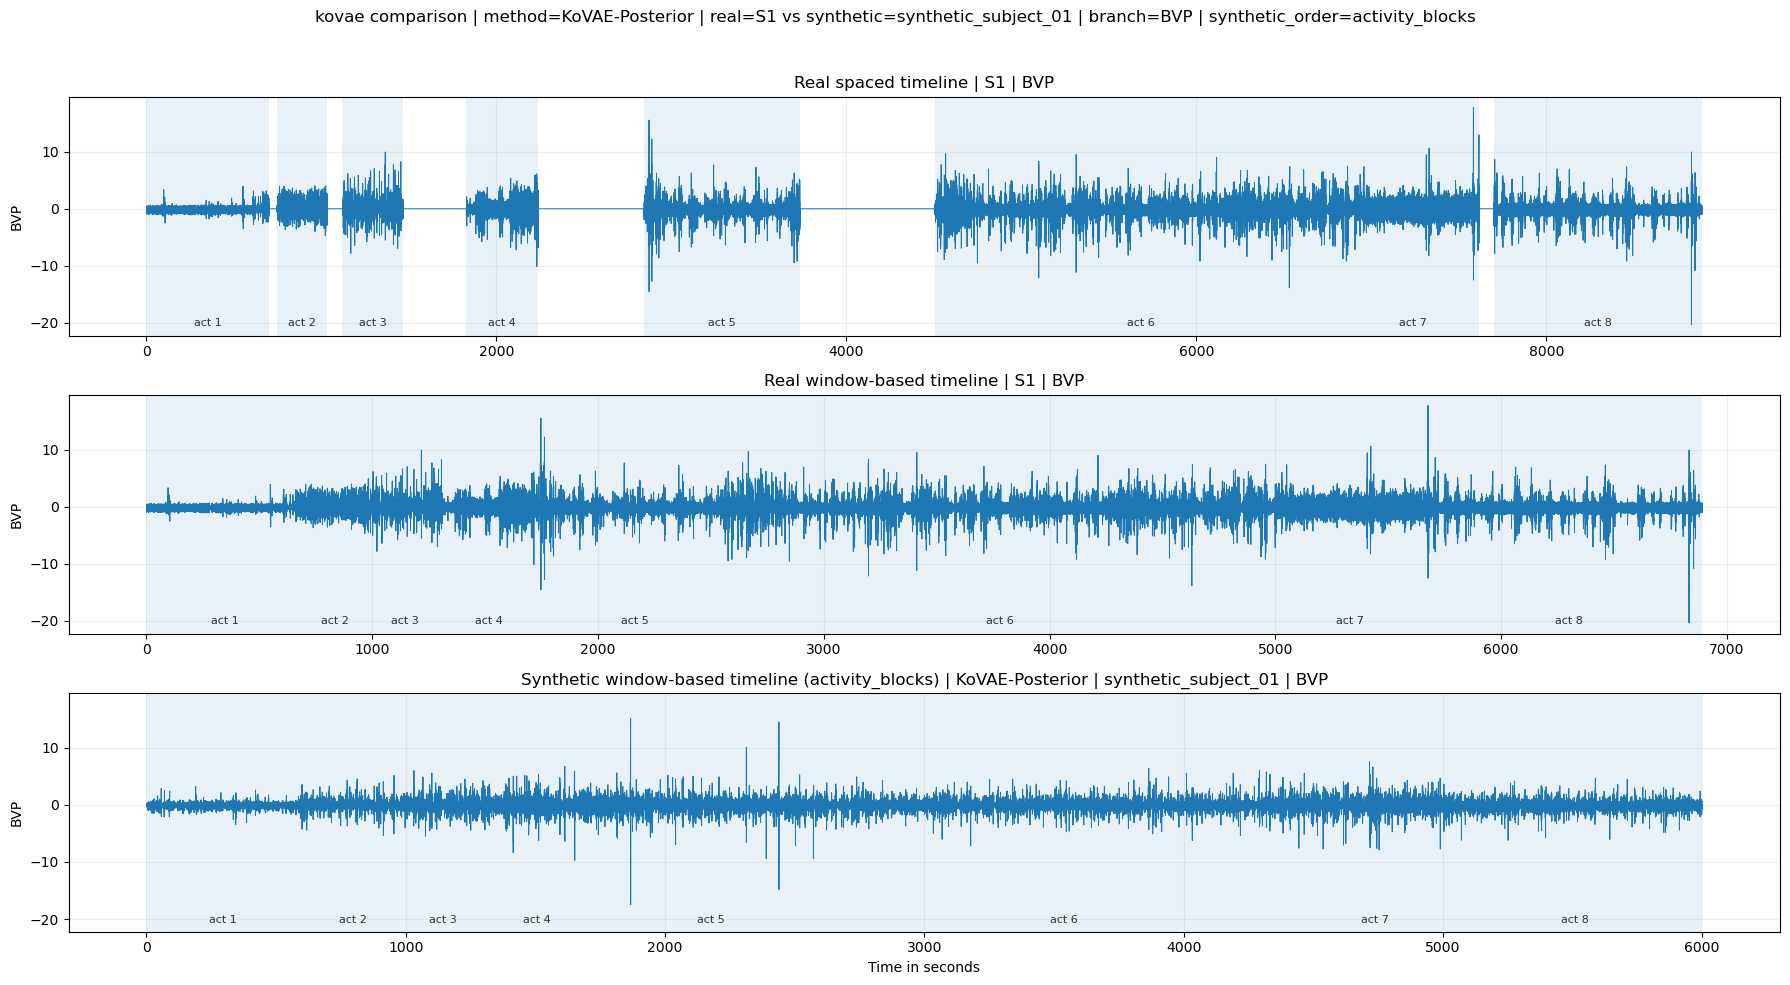


Processing branch: SLOW

--------------------------------------------------------------------------------
SYNTHETIC subject: synthetic_subject_01 | branch=SLOW

--------------------------------------------------------------------------------
REAL subject: S1 | branch=SLOW
Real S1 SLOW: windows=3445 | expected_shift_ratio=0.998 | median_diff=8.0 | max_diff=3112.0
Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2/three_way/S1_vs_synthetic_subject_01/SLOW_EDA_three_way.png


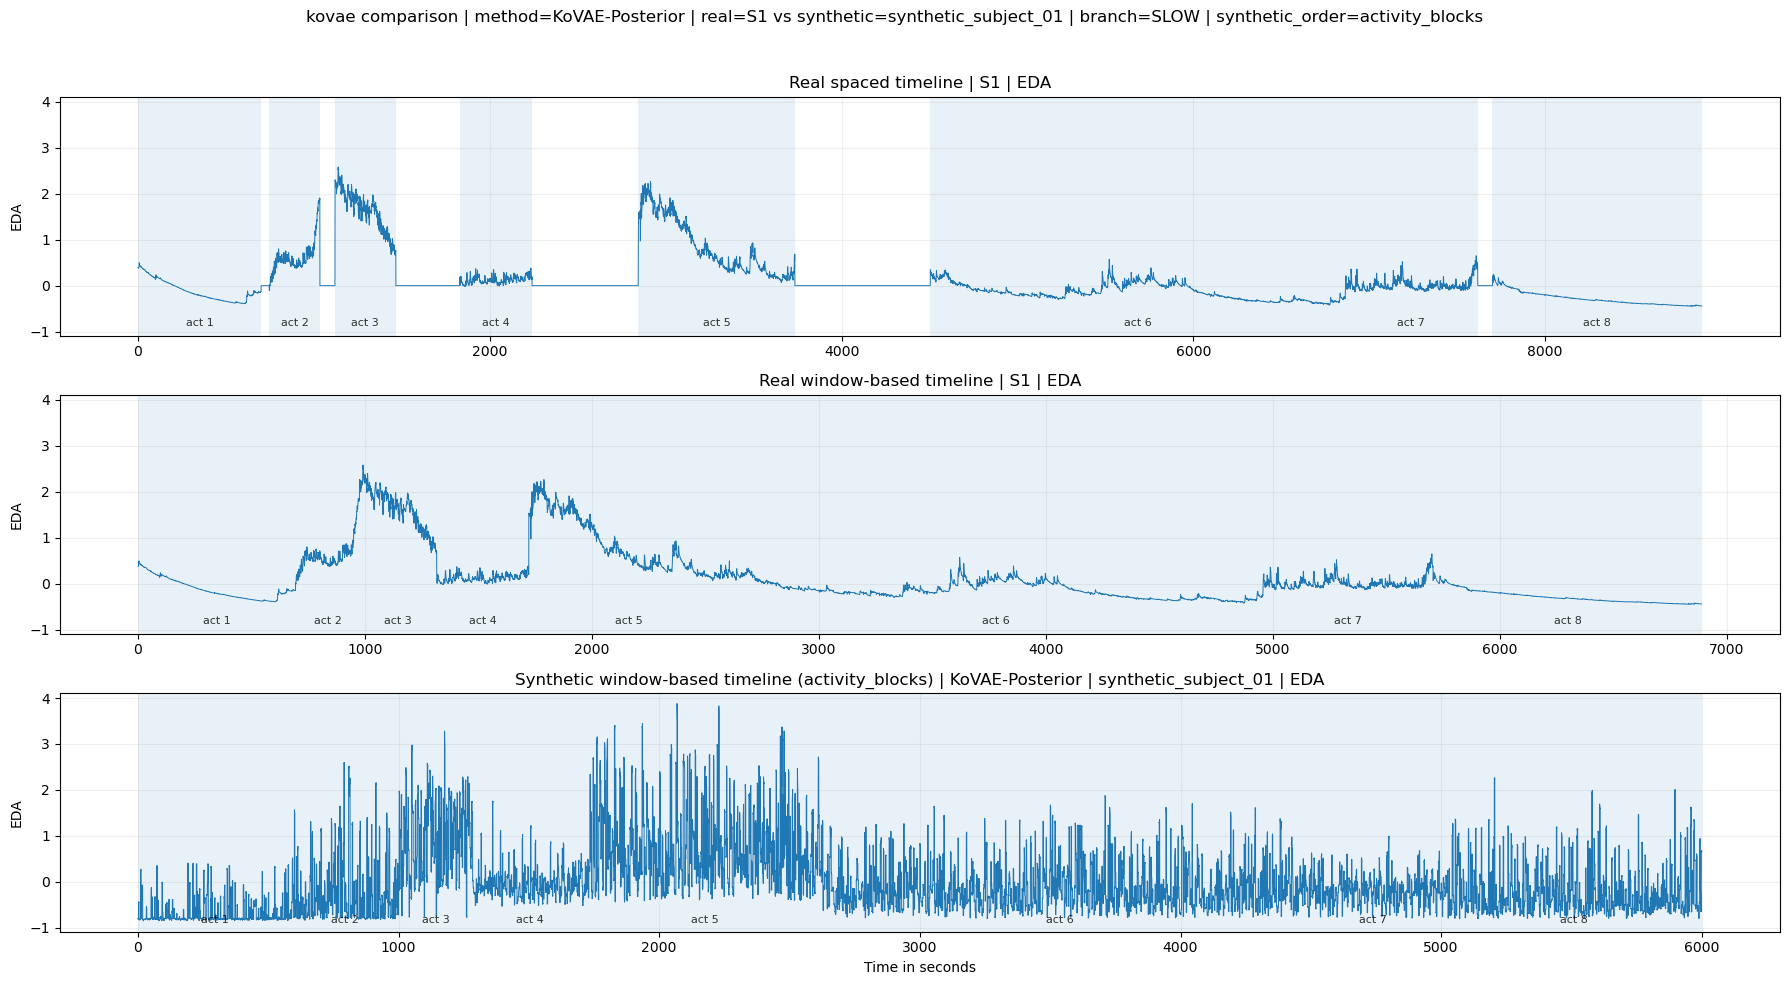

Saved: /home/iailab42/khans1/projects/ir/figures/comparison/kovae/posterior_bank_v2/three_way/S1_vs_synthetic_subject_01/SLOW_TEMP_three_way.png


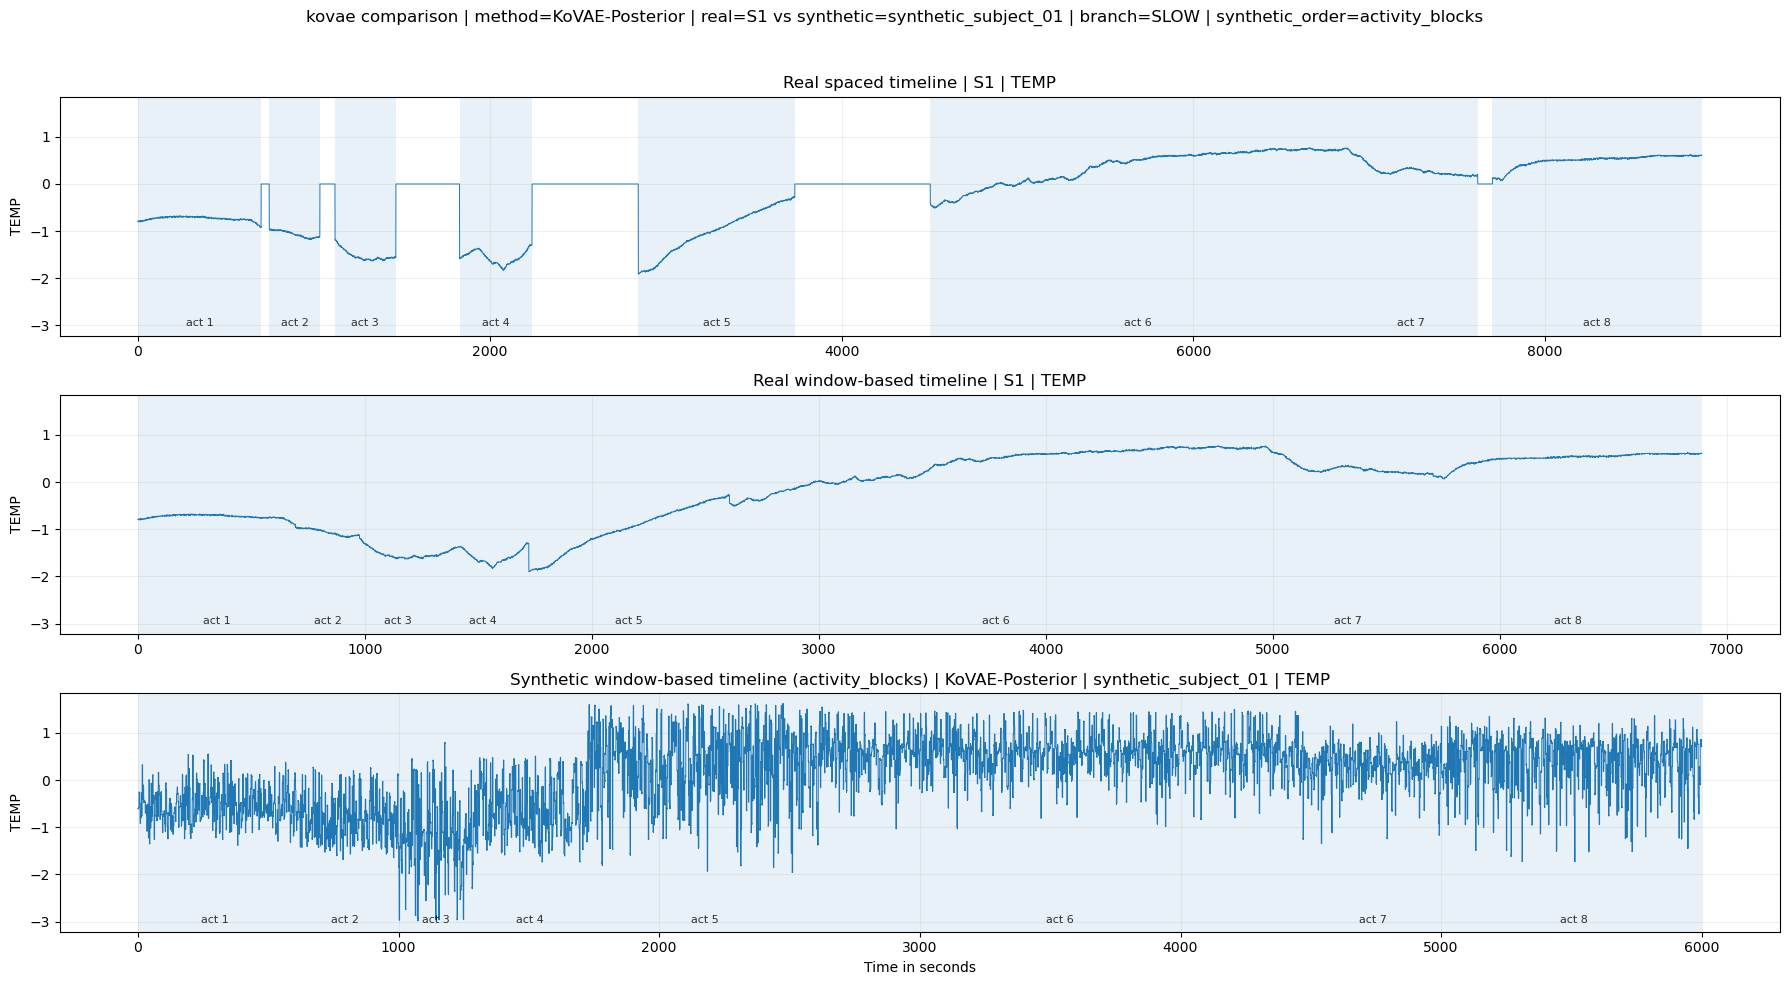

Saved: /home/iailab42/khans1/projects/ir/results/comparison/kovae/posterior_bank_v2/summaries/comparison_plot_summary.csv

Done.
Combined CSV: /home/iailab42/khans1/projects/ir/results/comparison/kovae/combined_comparison_plot_summary.csv
Combined JSON: /home/iailab42/khans1/projects/ir/results/comparison/kovae/combined_comparison_summary.json


{'model_family': 'kovae',
 'methods_to_compare': ['rollout_v1', 'posterior_bank_v2'],
 'method_display_names': {'rollout_v1': 'KoVAE-Rollout',
  'posterior_bank_v2': 'KoVAE-Posterior'},
 'synthetic_plot_order_mode': 'activity_blocks',
 'synthetic_reconstruction_mode': 'window_based',
 'figures_model_dir': '/home/iailab42/khans1/projects/ir/figures/comparison/kovae',
 'results_model_dir': '/home/iailab42/khans1/projects/ir/results/comparison/kovae',
 'combined_summary_csv': '/home/iailab42/khans1/projects/ir/results/comparison/kovae/combined_comparison_plot_summary.csv',
 'num_plot_rows': 12,
 'foldering_note': {'kovae': 'figures/comparison/kovae/<method>/ and results/comparison/kovae/<method>/',
  'future_timevae': 'figures/comparison/timevae/<method>/ and results/comparison/timevae/<method>/'}}

In [2]:
COMPARISON_CONFIG["model_family"] = "kovae"
COMPARISON_CONFIG["synthetic_base_dir"] = "data/synthetic_subjects/kovae"

COMPARISON_CONFIG["methods_to_compare"] = ["rollout_v1", "posterior_bank_v2"]
COMPARISON_CONFIG["method_display_names"] = {
    "rollout_v1": "KoVAE-Rollout",
    "posterior_bank_v2": "KoVAE-Posterior",
}

# Minimal comparison: only one real and one synthetic subject.
COMPARISON_CONFIG["real_subjects_to_compare"] = ["S1"]
COMPARISON_CONFIG["synthetic_subject_selection"] = "first_n"
COMPARISON_CONFIG["num_synthetic_subjects_to_compare"] = 1
COMPARISON_CONFIG["pairing_mode"] = "same_index"

COMPARISON_CONFIG["synthetic_plot_order_mode"] = "activity_blocks"
COMPARISON_CONFIG["synthetic_reconstruction_mode"] = "window_based"

COMPARISON_CONFIG["match_duration_for_three_way"] = False
COMPARISON_CONFIG["comparison_duration_sec"] = None
COMPARISON_CONFIG["comparison_start_sec"] = 0.0

COMPARISON_CONFIG["use_common_y_axis"] = True
COMPARISON_CONFIG["use_robust_y_axis"] = False
COMPARISON_CONFIG["plot_step"] = 1

COMPARISON_CONFIG["save_plot"] = True

# This is the key reduction.
COMPARISON_CONFIG["save_individual_plots"] = False
COMPARISON_CONFIG["save_three_way_plots"] = True
COMPARISON_CONFIG["save_continuous_arrays"] = False

outputs = main(COMPARISON_CONFIG)
outputs["combined_summary"]
